# AM 115 Group Project 2 - Analysis of Airport Security with Queuing Theory
By Kaylee Vo, Tadhg Scannell

# Baseline Models

- M/M/c queue, where c is the number of servers.

## Version 1

- This baseline model is an M/M/c queue, where c is the number of servers.
- The servers are shared between regular and TSA PreCheck passengers. Pooled servers.
- This is not parallel. There is no closed form solution for this model.

Distribution Assumptions

The interarrival times of the passengers are exponentially distributed with a mean of $\frac{1}{\lambda}$, where $\lambda$ is the arrival rate of passengers. The pdf is given by:

$$
a(t) =
\begin{cases}
  \lambda e^{-\lambda t} & \text{if } t \geq 0 \\
  0 & \text{if } t < 0
\end{cases}
$$

Interarrival times can be interpreted as "how long do I wait until the next person arrives?".

As for the service times, we also assume they are exponentially distributed, where $\mu$ is the service rate of the servers. The mean service time is $\frac{1}{\mu}$. The pdf is given by:

$$
b(t) =
\begin{cases}
  \mu e^{-\mu t} & \text{if } t \geq 0 \\
  0 & \text{if } t < 0
\end{cases}
$$

Memoryless Property

The exponential distribution is the only continous distribution with the memoryless property. Other distributions in the exponential family do not have this property. This means that the probability of waiting an additional time $t$ is independent of how long you have already waited.

$$
P(X > s + t | X > s) = P(X > t) \quad \forall s, t \geq 0
$$

In reality, this assumption is quite strong for service times because if service time has already been long, it is likely to be longer (i.e. dealing with a complex issue or unruly passenger). We'll relax this assumption later.


### Parameters Research

In [385]:
import heapq
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [386]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"

# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

In [387]:
# Parameters
# units are passengers per minute
ARRIVAL_RATE = 23.6

In [388]:
ARRIVAL_RATE

23.6

- See modeling notebook for parameter calculations.
- Sensitivity analysis on this. Use range from model fitting notebook.

In [389]:
# These are lower bounds
# Service rate for regular passengers, units are passengers per minute
SERVICE_RATE_REGULAR = 1.9701
# Faster service rate for TSA PreCheck
SERVICE_RATE_PRECHECK = 1.9701 * 1.33

In [390]:
SERVICE_RATE_REGULAR

1.9701

In [391]:
SERVICE_RATE_PRECHECK

2.6202330000000003

- For service rate, we make the simplifying assumption that it encompasses the process form id and boarding pass check to the end of the screening process where one picks up their bags at the end of the conveyor belt.
- Sources below provide an lower bound on service time. For regular it is 30 minutes per passenger, for TSA pre it's 19 minutes per passenger.
- TSA is quicker by 33%
- Sensitivity analysis on this. Keep the 1.33 factor.

Sources
- https://www.gao.gov/assets/gao-18-236.pdf

In [392]:
PRECHECK_PROB = 0.27  # Probability of being PreCheck


Sources
- https://www.gao.gov/assets/gao-18-236.pdf
    - "average of 27% of passengers use TSA PreCheck"
- https://www.washingtonpost.com/travel/2024/11/28/tsa-precheck-vs-standard-security-line/
- https://www.yahoo.com/news/reached-peak-precheck-233857724.html

In [393]:
NUM_SERVERS = 12

- Estimate from empirical data
- Sensivity analysis on this. Use range from lockheed martin data.

- https://www.trb.org/publications/circulars/ec060/06_Bradley.pdf
    - The data is noisy and doesn't have exact data on number of TSA screeners, just staff
    - We make the assumption that half of the staff are TSA PreCheck screeners
    - This gives us an average of 4.5 TSA PreCheck screeners, with a range of 2 to 12 across a whole day.

In [394]:
# 33987.54375
MAX_CUST = 34000

- Estimate from data
- 33987.54375

In [395]:
rho_reg = ARRIVAL_RATE / (NUM_SERVERS * SERVICE_RATE_REGULAR)
rho_pre = ARRIVAL_RATE / (NUM_SERVERS * SERVICE_RATE_PRECHECK)

print(f"rho_reg: {rho_reg:.4f}, rho_pre: {rho_pre:.4f}")
print(f"rho_reg < 1: {rho_reg < 1}, rho_pre < 1: {rho_pre < 1}")

rho_reg: 0.9983, rho_pre: 0.7506
rho_reg < 1: True, rho_pre < 1: True


### Simulation Functions

In [396]:
random.seed(42)

In [397]:
def record_wait_time(
    wait_time, is_precheck, wait_times_precheck, wait_times_regular, cid
):
    """Record wait time in appropriate list"""
    if is_precheck:
        wait_times_precheck[cid] = wait_time
    else:
        wait_times_regular[cid] = wait_time

In [398]:
def get_service_time(is_precheck, service_rate_precheck, service_rate_regular):
    """Generate service time based on customer type"""
    service_rate = service_rate_precheck if is_precheck else service_rate_regular
    return random.expovariate(service_rate)

In [399]:
def find_available_servers(servers_busy_until, current_time):
    """Find all available servers"""
    return [i for i, t in enumerate(servers_busy_until) if t <= current_time]

In [400]:
def assign_to_server_or_queue(
    servers_busy_until,
    current_time,
    is_precheck,
    service_rate_precheck,
    service_rate_regular,
    event_queue,
    cid,
    waiting_queue,
    priority,
    wait_times_precheck,
    wait_times_regular,
):
    """Assign customer to available server or add to waiting queue"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    if available_servers:
        server = available_servers[0]
        service_time = get_service_time(
            is_precheck, service_rate_precheck, service_rate_regular
        )
        servers_busy_until[server] = current_time + service_time

        record_wait_time(0.0, is_precheck, wait_times_precheck, wait_times_regular, cid)

        heapq.heappush(event_queue, (current_time + service_time, "departure", cid))
    else:
        heapq.heappush(waiting_queue, (priority, current_time, cid, is_precheck))

In [401]:
def handle_arrival_event(
    event_queue,
    current_time,
    cid,
    customer_id,
    arrival_rate,
    precheck_probability,
    servers_busy_until,
    service_rate_precheck,
    service_rate_regular,
    waiting_queue,
    wait_times_precheck,
    wait_times_regular,
    arrival_times_precheck,
    arrival_times_regular,
):
    """Process a customer arrival event"""

    # Schedule next arrival
    inter_arrival = random.expovariate(arrival_rate)
    heapq.heappush(event_queue, (current_time + inter_arrival, "arrival", customer_id))

    # Determine if PreCheck or regular
    is_precheck = random.random() < precheck_probability
    priority = 0 if is_precheck else 1

    # Record arrival time
    if is_precheck:
        arrival_times_precheck[cid] = current_time
    else:
        arrival_times_regular[cid] = current_time

    # Try to assign to server
    assign_to_server_or_queue(
        servers_busy_until,
        current_time,
        is_precheck,
        service_rate_precheck,
        service_rate_regular,
        event_queue,
        cid,
        waiting_queue,
        priority,
        wait_times_precheck,
        wait_times_regular,
    )

    return customer_id + 1

In [402]:
def handle_departure_event(
    event_queue,
    current_time,
    servers_busy_until,
    waiting_queue,
    service_rate_precheck,
    service_rate_regular,
    wait_times_precheck,
    wait_times_regular,
):
    """Process a server departure event"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    for server in available_servers:
        if waiting_queue:
            priority, arrival_time, queued_cid, is_precheck = heapq.heappop(
                waiting_queue
            )
            service_time = get_service_time(
                is_precheck, service_rate_precheck, service_rate_regular
            )
            servers_busy_until[server] = current_time + service_time

            wait_time = current_time - arrival_time
            record_wait_time(
                wait_time,
                is_precheck,
                wait_times_precheck,
                wait_times_regular,
                queued_cid,
            )

            heapq.heappush(
                event_queue, (current_time + service_time, "departure", queued_cid)
            )

In [403]:
random.seed(115)


def run_simulation(
    max_cust,
    arrival_rate,
    precheck_probability,
    service_rate_precheck,
    service_rate_regular,
    num_servers,
):
    """Main simulation function"""
    # System State
    event_queue = []
    waiting_queue = []
    servers_busy_until = [0.0] * num_servers
    wait_times_precheck = dict()
    wait_times_regular = dict()

    # For plotting layer
    arrival_times_precheck = dict()
    arrival_times_regular = dict()

    # Schedule first arrival
    heapq.heappush(event_queue, (0.0, "arrival", 0))
    customer_id = 1

    # Main event loop
    while event_queue:
        event_time, event_type, cid = heapq.heappop(event_queue)
        current_time = event_time

        if event_type == "arrival":
            if customer_id <= MAX_CUST:
                # Handle arrival event
                customer_id = handle_arrival_event(
                    event_queue,
                    current_time,
                    cid,
                    customer_id,
                    arrival_rate,
                    precheck_probability,
                    servers_busy_until,
                    service_rate_precheck,
                    service_rate_regular,
                    waiting_queue,
                    wait_times_precheck,
                    wait_times_regular,
                    arrival_times_precheck,
                    arrival_times_regular,
                )
        elif event_type == "departure":
            handle_departure_event(
                event_queue,
                current_time,
                servers_busy_until,
                waiting_queue,
                service_rate_precheck,
                service_rate_regular,
                wait_times_precheck,
                wait_times_regular,
            )

    return (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    )

In [404]:
def print_results(wait_times_precheck, wait_times_regular):
    """Print simulation results"""
    print(f"TSA PreCheck:")
    print(
        f"  Average wait time: {sum(wait_times_precheck) / len(wait_times_precheck):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_precheck)):.2f}")
    print(f"  Max wait time: {max(wait_times_precheck):.2f}")

    print(f"\nRegular Passengers:")
    print(
        f"  Average wait time: {sum(wait_times_regular) / len(wait_times_regular):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_regular)):.2f}")
    print(f"  Max wait time: {max(wait_times_regular):.2f}")

### Single Simulation

In [405]:
stats_tuple = run_simulation(
    MAX_CUST,
    ARRIVAL_RATE,
    PRECHECK_PROB,
    SERVICE_RATE_PRECHECK,
    SERVICE_RATE_REGULAR,
    NUM_SERVERS,
)

# Unpack the results
(
    wait_times_precheck,
    wait_times_regular,
    arrival_times_precheck,
    arrival_times_regular,
) = stats_tuple

In [406]:
print_results(
    np.array(list(wait_times_precheck.values())),
    np.array(list(wait_times_regular.values())),
)

TSA PreCheck:
  Average wait time: 0.04
  Variance of wait times: 0.00
  Max wait time: 0.45

Regular Passengers:
  Average wait time: 0.52
  Variance of wait times: 0.48
  Max wait time: 3.82


In [407]:
def calculate_throughput(arrival_times, wait_times, total_simulation_time):
    """Calculate throughput (passengers/minute) for a passenger type"""
    served_passengers = [cid for cid, wt in wait_times.items() if wt != float("inf")]
    return len(served_passengers) / total_simulation_time


# Get the final simulation time (last event time)
total_time = max(
    max(arrival_times_precheck.values(), default=0),
    max(arrival_times_regular.values(), default=0),
)

# Calculate throughputs
throughput_precheck = calculate_throughput(
    arrival_times_precheck, wait_times_precheck, total_time
)

throughput_regular = calculate_throughput(
    arrival_times_regular, wait_times_regular, total_time
)

print(f"PreCheck Throughput: {throughput_precheck:.2f} passengers/minute")
print(f"Regular Throughput: {throughput_regular:.2f} passengers/minute")

PreCheck Throughput: 6.33 passengers/minute
Regular Throughput: 17.21 passengers/minute


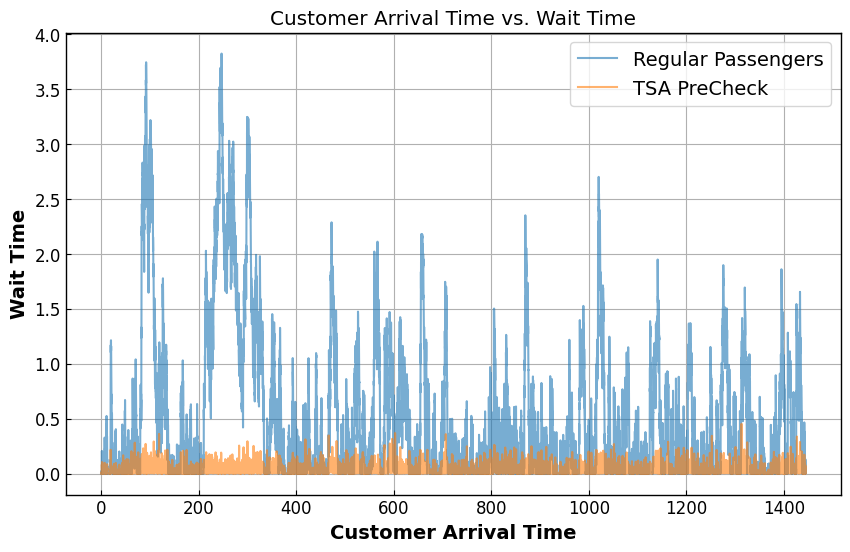

In [408]:
# Extract data for plotting
y1_wait_times_regular = [wait_times_regular[cid] for cid in wait_times_regular.keys()]
y2_wait_times_precheck = [
    wait_times_precheck[cid] for cid in wait_times_precheck.keys()
]
x1 = [arrival_times_regular[cid] for cid in wait_times_regular.keys()]
x2 = [arrival_times_precheck[cid] for cid in wait_times_precheck.keys()]

plt.figure(figsize=(10, 6))
plt.plot(x1, y1_wait_times_regular, label="Regular Passengers", alpha=0.6)
plt.plot(x2, y2_wait_times_precheck, label="TSA PreCheck", alpha=0.6)
plt.xlabel("Customer Arrival Time")
plt.ylabel("Wait Time")
plt.title("Customer Arrival Time vs. Wait Time")
plt.legend()
plt.grid(True)
plt.savefig("./plots/trace_plot.png")
plt.show()

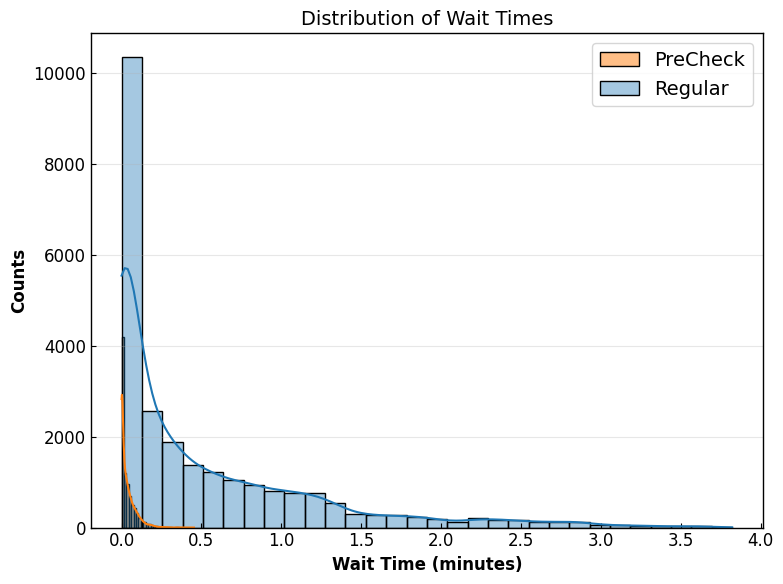

In [409]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(
    list(wait_times_precheck.values()),
    bins=30,
    kde=True,
    color=sns.color_palette()[1],
    label="PreCheck",
)
sns.histplot(
    list(wait_times_regular.values()),
    bins=30,
    kde=True,
    color=sns.color_palette()[0],
    label="Regular",
    alpha=0.4,
)
plt.xlabel("Wait Time (minutes)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.title("Distribution of Wait Times", fontsize=14)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("./plots/wait_time_distribution.png")
plt.show()

### Multiple Simulations

In [410]:
num_sims = 500
wait_times_precheck_list = []
wait_times_regular_list = []
arrival_times_precheck_list = []
arrival_times_regular_list = []
throughput_precheck_list = []
throughput_regular_list = []

for _ in range(num_sims):
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        PRECHECK_PROB,
        SERVICE_RATE_PRECHECK,
        SERVICE_RATE_REGULAR,
        NUM_SERVERS,
    )

    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    wait_times_precheck_list.extend(list(wait_times_precheck.values()))
    wait_times_regular_list.extend(list(wait_times_regular.values()))
    arrival_times_precheck_list.extend(list(arrival_times_precheck.values()))
    arrival_times_regular_list.extend(list(arrival_times_regular.values()))

    # Get the final simulation time (last event time)
    total_time = max(
        max(arrival_times_precheck.values(), default=0),
        max(arrival_times_regular.values(), default=0),
    )

    # Calculate throughputs
    throughput_precheck = calculate_throughput(
        arrival_times_precheck, wait_times_precheck, total_time
    )

    throughput_regular = calculate_throughput(
        arrival_times_regular, wait_times_regular, total_time
    )
    throughput_precheck_list.append(throughput_precheck)
    throughput_regular_list.append(throughput_regular)

In [411]:
print_results(np.array(wait_times_precheck_list), np.array(wait_times_regular_list))

TSA PreCheck:
  Average wait time: 0.04
  Variance of wait times: 0.00
  Max wait time: 0.75

Regular Passengers:
  Average wait time: 0.53
  Variance of wait times: 0.49
  Max wait time: 9.79


In [412]:
print(
    f"Average PreCheck Throughput: {np.mean(throughput_precheck_list):.2f} passengers/minute"
)
print(
    f"Average Regular Throughput: {np.mean(throughput_regular_list):.2f} passengers/minute"
)

Average PreCheck Throughput: 6.37 passengers/minute
Average Regular Throughput: 17.22 passengers/minute


- Throughput is higher for regular passengers because they have a higher arrival rate and the system is stable.

In [413]:
avg_precheck = np.mean(wait_times_precheck_list)
avg_regular = np.mean(wait_times_regular_list)

weighted_avg = avg_precheck * PRECHECK_PROB + avg_regular * (1 - PRECHECK_PROB)
weighted_avg

np.float64(0.39847317934475807)

In [414]:
# rho_reg: 0.9983, rho_pre: 0.7506

Reports Table

||  Average Wait Time (min) | Max Wait Time (min) | Average Throughput (passengers/min) | $\rho$ |
|-----| ---- | ---- | ---- | ---- |
| PreCheck | 0.04 | 0.75 | 6.37 | 0.75 |
| Regular | 0.53 | 9.79 | 17.22 | 0.998 |

In [415]:
## Optimization

$$
T(s, \mu) = c_ss + (c_{\mu} \mu^3) s + c_wL
$$
- $c_s$: cost of a server per hour
    - Can be interpreted as base pay
- $c_w$: cost of a customer waiting per hour
- $\mu$: service rate of the servers
- $c_{\mu}$: cost of a service rate per server per hour
    - Can be interpreted as bonus pay
- $L$: average number of customers in the system
- $s$: number of servers

The decision variables are $s$ and $\mu$.

In [416]:
# Cost parameters (per minute)
cs = 30 / 60  # $20/hour → ~$0.33/minute per server
cw = 37 / 60  # $15/hour → $0.25/minute per customer in system
cmu = cs * 0.06

# Arrival & Service Rates (per minute)
lam = ARRIVAL_RATE
mu = np.mean(
    [SERVICE_RATE_REGULAR, SERVICE_RATE_PRECHECK]
)  # average service rate (passengers/minute)

s = 12  # servers

- TSA agent average wage is $28 hour

In [417]:
SERVICE_RATE_PRECHECK * 1.33

3.4849098900000004

In [418]:
import numpy as np
from scipy.special import factorial
from scipy.optimize import minimize


def erlang_c(s, mu, lam):
    rho = lam / (s * mu)
    if rho >= 1:
        return np.inf  # unstable system, infinite queue

    s_int = int(np.floor(s))
    # Sum of terms for states 0 to s-1
    sum_terms = sum((s * rho) ** n / factorial(n) for n in range(s_int))
    numerator = ((s * rho) ** s_int / factorial(s_int)) * (1 / (1 - rho))
    denom = sum_terms + numerator
    P_wait = numerator / denom

    Lq = P_wait * (rho / (1 - rho))
    Ls = Lq + lam / mu
    return Ls


def total_cost(x):
    s, mu = x
    if s < 1 or mu <= 0:
        return 1e10  # Penalize invalid parameters

    Ls = erlang_c(s, mu, lam)
    if Ls == np.inf:
        return 1e10  # Penalize unstable systems

    # return cs * s + cw * Ls + cmu * np.exp(0.8 * mu) * s
    return cs * s + cw * Ls + cmu * mu**3 * s


# Initial guess: servers=5, service rate=1
x0 = [11, 1]
server_bounds = (3, 15)
service_rate_bounds = (0.5, SERVICE_RATE_PRECHECK * 1.33)

bounds = [
    server_bounds,
    service_rate_bounds,
]

from scipy.optimize import basinhopping

result = basinhopping(
    total_cost,
    x0,
    niter=1000,
    T=1.0,
    stepsize=0.5,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "bounds": bounds,
        "options": {
            "gtol": 1e-8,
            "maxiter": 1000,
            "finite_diff_rel_step": 1e-8,
        },
    },
)

opt_s, opt_mu = result.x
print(f"Optimal number of servers: {opt_s:.2f}")
print(f"Optimal service rate per server: {opt_mu:.2f}")
print(f"Minimum total cost: {result.fun:.2f}")

Optimal number of servers: 12.00
Optimal service rate per server: 2.44
Minimum total cost: 18.17


- x^3 because starts off slower than x^2 then grows rapidly overtaking x^2.
- mimics the cost to increasing service rate. You can incentivize small gains but it takes much more to push a person because humans have capacity limits.

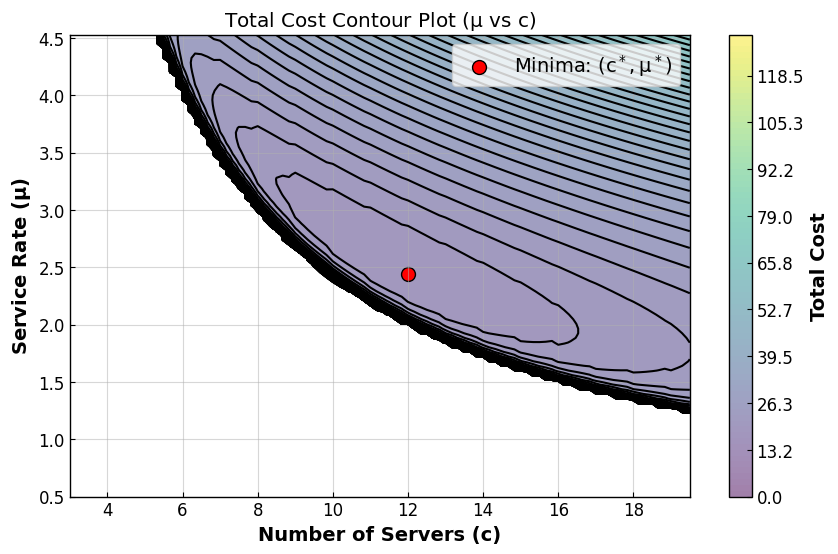

In [419]:
# Create a grid of s and mu values
s_values = np.linspace(server_bounds[0], server_bounds[1] * 1.3, 100)
mu_values = np.linspace(service_rate_bounds[0], service_rate_bounds[1] * 1.3, 100)

# Compute total cost for each combination
S, MU = np.meshgrid(s_values, mu_values)
Cost = np.zeros_like(S)

for i in range(len(s_values)):
    for j in range(len(mu_values)):
        Cost[j, i] = total_cost([S[j, i], MU[j, i]])

# Plot contour lines
plt.figure(figsize=(10, 6))
contour_levels = np.linspace(0, 130, 80)  # Adjust levels as needed
contour_plot = plt.contour(S, MU, Cost, levels=contour_levels, colors="k")

# Add color gradient (optional)
plt.contourf(S, MU, Cost, levels=contour_levels, cmap="viridis", alpha=0.5)
plt.colorbar(label="Total Cost")

# Mark the optimal point (if known)
optimal_s = result.x[0]
optimal_mu = result.x[1]
plt.scatter(
    optimal_s,
    optimal_mu,
    color="red",
    label="Minima: ($c^*, \\mu^*$)",
    s=100,
    edgecolor="black",
)

# Labels and title
plt.xlabel("Number of Servers (c)")
plt.ylabel("Service Rate ($\\mu$)")
plt.title("Total Cost Contour Plot ($\\mu$ vs c)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.savefig("./plots/loss_surface.png")
plt.show()

## Version 2

- This baseline model is an M/M/c queue, where c is the number of servers.
- The lines are parallel. There is a dedicated server for each line, regular and precheck. this is more akin to CLEAR than precheck (fun fact).
- This model has a closed form solution.

In [420]:
# Parameters (units: passengers per minute)
ARRIVAL_RATE_REGULAR = 23.6
PRECHECK_PROB = 0.27
ARRIVAL_RATE_PRECHECK = ARRIVAL_RATE_REGULAR * PRECHECK_PROB

SERVICE_RATE_REGULAR = 1.9701
SERVICE_RATE_PRECHECK = SERVICE_RATE_REGULAR * 1.33

NUM_SERVERS = 12
MAX_CUST = 34000

# Initialize server pools (25% PreCheck, 75% regular)
servers_precheck = [0.0] * int(NUM_SERVERS * 0.2)
servers_regular = [0.0] * int(NUM_SERVERS * 0.8)

In [421]:
rho = ARRIVAL_RATE_REGULAR / (len(servers_regular) * SERVICE_RATE_REGULAR)
rho

1.3310097062190867

In [422]:
rho = ARRIVAL_RATE_PRECHECK / (len(servers_precheck) * SERVICE_RATE_PRECHECK)
rho

1.2159224007941278

- Right off the bat, the stability condition is not satisfied with the parallel system. This means the priority queue version is better than the parallel system approach.
- This harkens back to the class poll on whether we should divide up resources or not. The answer in class wa no.

## Sensitivity Analysis

In [423]:
def record_wait_time(
    wait_time, is_precheck, wait_times_precheck, wait_times_regular, cid
):
    """Record wait time in appropriate list"""
    if is_precheck:
        wait_times_precheck[cid] = wait_time
    else:
        wait_times_regular[cid] = wait_time

In [424]:
def get_service_time(is_precheck, service_rate_precheck, service_rate_regular):
    """Generate service time based on customer type"""
    service_rate = service_rate_precheck if is_precheck else service_rate_regular
    return random.expovariate(service_rate)

In [425]:
def find_available_servers(servers_busy_until, current_time):
    """Find all available servers"""
    return [i for i, t in enumerate(servers_busy_until) if t <= current_time]

In [426]:
def assign_to_server_or_queue(
    servers_busy_until,
    current_time,
    is_precheck,
    service_rate_precheck,
    service_rate_regular,
    event_queue,
    cid,
    waiting_queue,
    priority,
    wait_times_precheck,
    wait_times_regular,
):
    """Assign customer to available server or add to waiting queue"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    if available_servers:
        server = available_servers[0]
        service_time = get_service_time(
            is_precheck, service_rate_precheck, service_rate_regular
        )
        servers_busy_until[server] = current_time + service_time

        record_wait_time(0.0, is_precheck, wait_times_precheck, wait_times_regular, cid)

        heapq.heappush(event_queue, (current_time + service_time, "departure", cid))
    else:
        heapq.heappush(waiting_queue, (priority, current_time, cid, is_precheck))

In [427]:
def handle_arrival_event(
    event_queue,
    current_time,
    cid,
    customer_id,
    arrival_rate,
    precheck_probability,
    servers_busy_until,
    service_rate_precheck,
    service_rate_regular,
    waiting_queue,
    wait_times_precheck,
    wait_times_regular,
    arrival_times_precheck,
    arrival_times_regular,
):
    """Process a customer arrival event"""

    # Schedule next arrival
    inter_arrival = random.expovariate(arrival_rate)
    heapq.heappush(event_queue, (current_time + inter_arrival, "arrival", customer_id))

    # Determine if PreCheck or regular
    is_precheck = random.random() < precheck_probability
    priority = 0 if is_precheck else 1

    # Record arrival time
    if is_precheck:
        arrival_times_precheck[cid] = current_time
    else:
        arrival_times_regular[cid] = current_time

    # Try to assign to server
    assign_to_server_or_queue(
        servers_busy_until,
        current_time,
        is_precheck,
        service_rate_precheck,
        service_rate_regular,
        event_queue,
        cid,
        waiting_queue,
        priority,
        wait_times_precheck,
        wait_times_regular,
    )

    return customer_id + 1

In [428]:
def handle_departure_event(
    event_queue,
    current_time,
    servers_busy_until,
    waiting_queue,
    service_rate_precheck,
    service_rate_regular,
    wait_times_precheck,
    wait_times_regular,
):
    """Process a server departure event"""
    available_servers = find_available_servers(servers_busy_until, current_time)

    for server in available_servers:
        if waiting_queue:
            priority, arrival_time, queued_cid, is_precheck = heapq.heappop(
                waiting_queue
            )
            service_time = get_service_time(
                is_precheck, service_rate_precheck, service_rate_regular
            )
            servers_busy_until[server] = current_time + service_time

            wait_time = current_time - arrival_time
            record_wait_time(
                wait_time,
                is_precheck,
                wait_times_precheck,
                wait_times_regular,
                queued_cid,
            )

            heapq.heappush(
                event_queue, (current_time + service_time, "departure", queued_cid)
            )

In [429]:
def run_simulation(
    max_cust,
    arrival_rate,
    precheck_probability,
    service_rate_precheck,
    service_rate_regular,
    num_servers,
):
    """Main simulation function"""
    # System State
    event_queue = []
    waiting_queue = []
    servers_busy_until = [0.0] * num_servers
    wait_times_precheck = dict()
    wait_times_regular = dict()

    # For plotting layer
    arrival_times_precheck = dict()
    arrival_times_regular = dict()

    # Schedule first arrival
    heapq.heappush(event_queue, (0.0, "arrival", 0))
    customer_id = 1

    # Main event loop
    while event_queue:
        event_time, event_type, cid = heapq.heappop(event_queue)
        current_time = event_time

        if event_type == "arrival":
            if customer_id <= MAX_CUST:
                # Handle arrival event
                customer_id = handle_arrival_event(
                    event_queue,
                    current_time,
                    cid,
                    customer_id,
                    arrival_rate,
                    precheck_probability,
                    servers_busy_until,
                    service_rate_precheck,
                    service_rate_regular,
                    waiting_queue,
                    wait_times_precheck,
                    wait_times_regular,
                    arrival_times_precheck,
                    arrival_times_regular,
                )
        elif event_type == "departure":
            handle_departure_event(
                event_queue,
                current_time,
                servers_busy_until,
                waiting_queue,
                service_rate_precheck,
                service_rate_regular,
                wait_times_precheck,
                wait_times_regular,
            )

    return (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    )

### Number of Servers

In [430]:
# We double
c_candidates = np.arange(3, 26)

In [431]:
stats_dict = {}

for c in c_candidates:
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        PRECHECK_PROB,
        SERVICE_RATE_PRECHECK,
        SERVICE_RATE_REGULAR,
        c,
    )

    # Unpack the results
    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    avg_precheck = np.mean(list(wait_times_precheck.values()))
    avg_regular = np.mean(list(wait_times_regular.values()))
    max_precheck = max(wait_times_precheck.values())
    max_regular = max(wait_times_regular.values())

    stats_dict[c] = {
        "avg_precheck": avg_precheck,
        "avg_regular": avg_regular,
        "max_precheck": max_precheck,
        "max_regular": max_regular,
    }

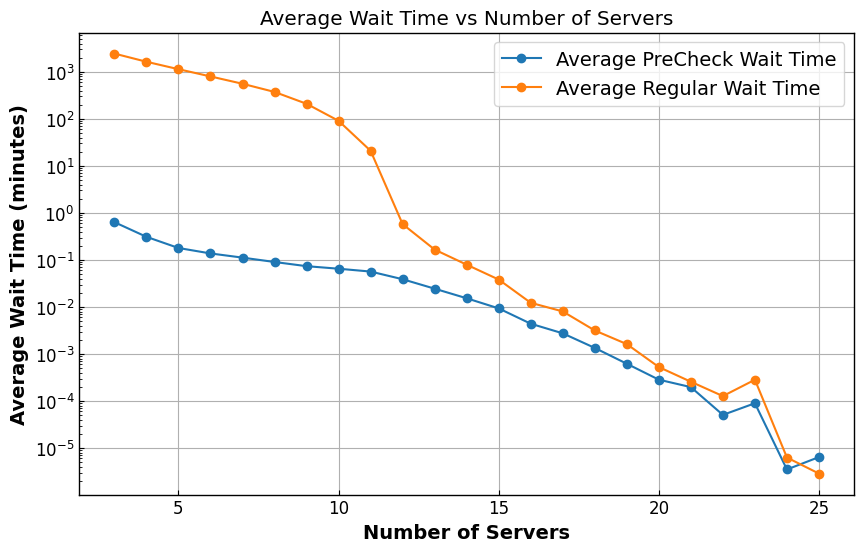

In [432]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    list(stats_dict.keys()),
    [stats_dict[c]["avg_precheck"] for c in stats_dict],
    label="Average PreCheck Wait Time",
    marker="o",
)
ax.plot(
    list(stats_dict.keys()),
    [stats_dict[c]["avg_regular"] for c in stats_dict],
    label="Average Regular Wait Time",
    marker="o",
)
ax.set_xlabel("Number of Servers")
ax.set_ylabel("Average Wait Time (minutes)")
ax.set_yscale("log")
ax.set_title("Average Wait Time vs Number of Servers")
ax.legend()
ax.grid(True)
plt.savefig("./plots/num_servers_sens.png")
plt.show()

### Services Rates

In [433]:
service_rate_regular_candidates = np.linspace(
    SERVICE_RATE_REGULAR * 0.5, SERVICE_RATE_REGULAR * 1.5, 100
)
service_rate_precheck_candidates = service_rate_regular_candidates * 1.33

In [434]:
stats_dict = {}

for service_rate_regular, service_rate_precheck in zip(
    service_rate_regular_candidates, service_rate_precheck_candidates
):
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        PRECHECK_PROB,
        service_rate_precheck,
        service_rate_regular,
        NUM_SERVERS,
    )

    # Unpack the results
    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    avg_precheck = np.mean(list(wait_times_precheck.values()))
    avg_regular = np.mean(list(wait_times_regular.values()))
    max_precheck = max(wait_times_precheck.values())
    max_regular = max(wait_times_regular.values())

    stats_dict[service_rate_regular] = {
        "avg_precheck": avg_precheck,
        "avg_regular": avg_regular,
        "max_precheck": max_precheck,
        "max_regular": max_regular,
    }

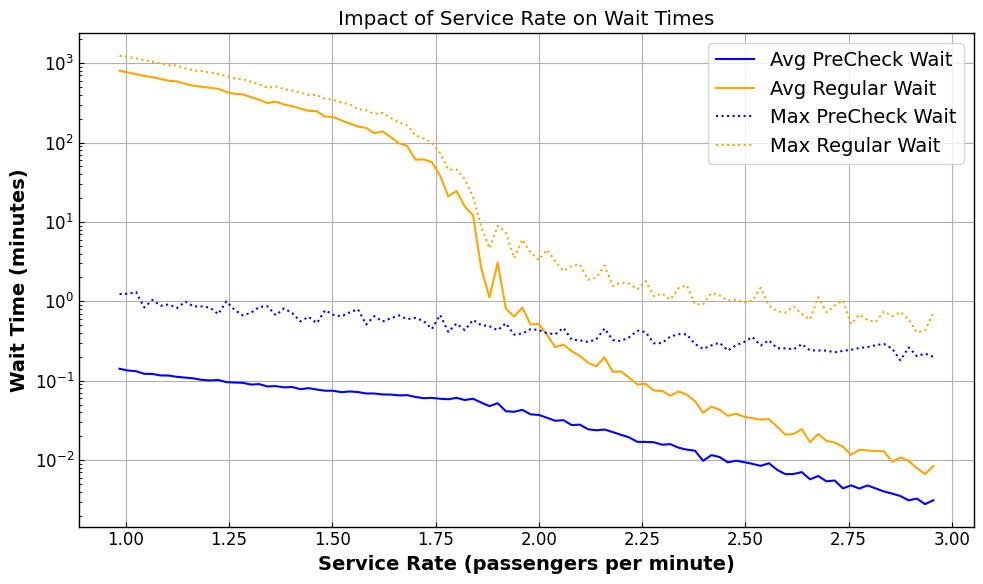

In [435]:
fig, ax = plt.subplots(figsize=(10, 6))

service_rate_regular = list(stats_dict.keys())
avg_precheck_values = [stat["avg_precheck"] for stat in stats_dict.values()]
avg_regular_values = [stat["avg_regular"] for stat in stats_dict.values()]
max_precheck_values = [stat["max_precheck"] for stat in stats_dict.values()]
max_regular_values = [stat["max_regular"] for stat in stats_dict.values()]

ax.plot(
    service_rate_regular,
    avg_precheck_values,
    label="Avg PreCheck Wait",
    color="blue",
)
ax.plot(
    service_rate_regular,
    avg_regular_values,
    label="Avg Regular Wait",
    color="orange",
)
ax.plot(
    service_rate_regular,
    max_precheck_values,
    label="Max PreCheck Wait",
    linestyle=":",
    color="blue",
)
ax.plot(
    service_rate_regular,
    max_regular_values,
    label="Max Regular Wait",
    linestyle=":",
    color="orange",
)
ax.set_xlabel("Service Rate (passengers per minute)")
ax.set_ylabel("Wait Time (minutes)")
ax.set_title("Impact of Service Rate on Wait Times")
ax.legend()
ax.set_yscale("log")
ax.grid(True)
plt.tight_layout()
plt.show()

### PreCheck Probability

In [436]:
# range from 1% of customers to 50% of customers
precheck_prob_candidates = np.linspace(0.01, 0.6, 100)

stats_dict = {}

for precheck_prob in precheck_prob_candidates:
    stats_tuple = run_simulation(
        MAX_CUST,
        ARRIVAL_RATE,
        precheck_prob,
        SERVICE_RATE_PRECHECK,
        SERVICE_RATE_REGULAR,
        NUM_SERVERS,
    )

    # Unpack the results
    (
        wait_times_precheck,
        wait_times_regular,
        arrival_times_precheck,
        arrival_times_regular,
    ) = stats_tuple

    avg_precheck = np.mean(list(wait_times_precheck.values()))
    avg_regular = np.mean(list(wait_times_regular.values()))

    # Get the final simulation time (last event time)
    total_time = max(
        max(arrival_times_precheck.values(), default=0),
        max(arrival_times_regular.values(), default=0),
    )

    # Calculate throughputs
    throughput_precheck = calculate_throughput(
        arrival_times_precheck, wait_times_precheck, total_time
    )

    throughput_regular = calculate_throughput(
        arrival_times_regular, wait_times_regular, total_time
    )

    stats_dict[precheck_prob] = {
        "avg_precheck": avg_precheck,
        "avg_regular": avg_regular,
        "throughput_precheck": throughput_precheck,
        "throughput_regular": throughput_regular,
    }

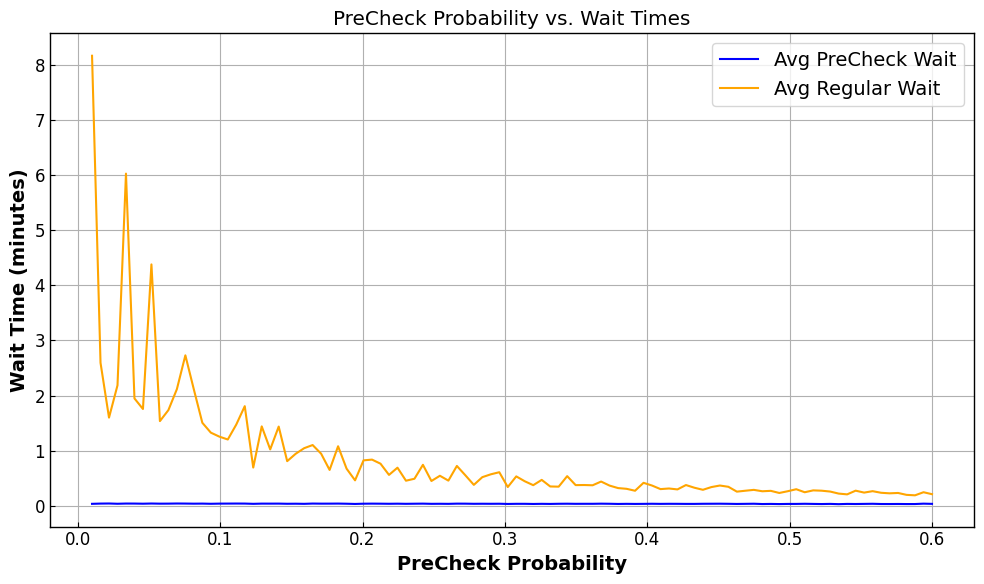

In [437]:
fig, ax = plt.subplots(figsize=(10, 6))

precheck_prob_candidates = list(stats_dict.keys())
avg_precheck_values = [stat["avg_precheck"] for stat in stats_dict.values()]
avg_regular_values = [stat["avg_regular"] for stat in stats_dict.values()]

ax.plot(
    precheck_prob_candidates,
    avg_precheck_values,
    label="Avg PreCheck Wait",
    color="blue",
)
ax.plot(
    precheck_prob_candidates,
    avg_regular_values,
    label="Avg Regular Wait",
    color="orange",
)
ax.set_xlabel("PreCheck Probability")
ax.set_ylabel("Wait Time (minutes)")
ax.set_title("PreCheck Probability vs. Wait Times")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

- In a pooled queue, it makes sense that precheck probability doesn't crowd out regular passengers. In fact it is beneficial because it reduces the number of regular passengers in the system.
- PreCheck is also faster as well.

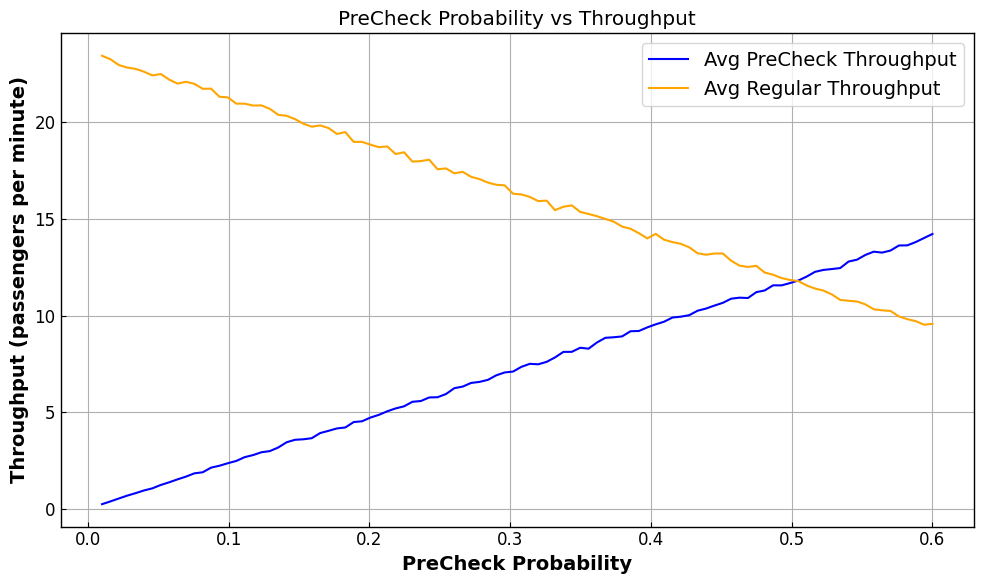

In [438]:
fig, ax = plt.subplots(figsize=(10, 6))

precheck_prob_candidates = list(stats_dict.keys())
avg_precheck_values = [stat["throughput_precheck"] for stat in stats_dict.values()]
avg_regular_values = [stat["throughput_regular"] for stat in stats_dict.values()]

ax.plot(
    precheck_prob_candidates,
    avg_precheck_values,
    label="Avg PreCheck Throughput",
    color="blue",
)
ax.plot(
    precheck_prob_candidates,
    avg_regular_values,
    label="Avg Regular Throughput",
    color="orange",
)
ax.set_xlabel("PreCheck Probability")
ax.set_ylabel("Throughput (passengers per minute)")
ax.set_title("PreCheck Probability vs Throughput")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Single Checkpoint Simulation

# Functions

**TSA PreCheck Function**

Models a single TSA PreCHeck Security Screening

Uses a normal distribution for the service times.

In [439]:
def TSA_Precheck_Line(a, service_mean, service_std, ncust):
    """
    Simulates an M/N/1 queue for TSA Precheck.

    Inputs:
       a: average number of arrivals per minute.
       service_mean: mean service time per customer.
       service_std: standard deviation of service time.
       ncust: number of customers to simulate.
    Outputs:
       at = arrival time of a person joining the queue.
       st = service time once they reach the front.
       ft = finish time after waiting and being served.
       wt = waiting time before being served.
    """
    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times assuming an normal distribution
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    server_one_available_times = [0]



    # Compute finish times
    ft = np.zeros(ncust)
    ft[0] = at[0] + st[0]  # First customer's finish time

    # compute finish time for each customer as the larger of
    # arrival time plus service time (if no wait)
    # finish time of previous customer plus service time (if wait)
    for i in range(1, ncust):
        if at[i] < ft[i - 1]:
            wt[i] = ft[i - 1] - at[i]
            ft[i] = ft[i - 1] + st[i]
        else:
            wt[i] = 0
            ft[i] = at[i] + st[i]

    return at, ft, st, wt

**Standard Screening Function**

Models a screening checkpoint with 3 servers.

In [440]:
def Regular_Security_Line(a, service_mean, service_std, ncust):
    """
    Simulates an M/M/3 queue with normal service times.

    Inputs:
       a: average number of arrivals per minute
       service_mean: mean service time per customer
       service_std: standard deviation of service time
       ncust: number of customers to simulate
    Outputs:
       at = arrival time of a person joining the queue
       st = service time once they reach the front
       ft = finish time after waiting and being served
       wt = waiting time in queue before service begins
    """
    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times using normal distribution
    # Ensure service times are positive by using absolute value or truncation
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    # Initialize arrays for results
    ft = np.zeros(ncust)  # Finish times
    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    # Track when each server becomes available
    server_one_available_times = [0]
    server_two_available_times = [0]
    server_three_available_times = [0]


    for i in range(ncust):
        # Find the earliest available server
        if server_one_available_times[-1] <= server_two_available_times[-1] and server_one_available_times[-1] <= server_three_available_times[-1]:
            earliest_available_time = server_one_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_one_available_times.append(ft[i])

        elif server_two_available_times[-1] <= server_three_available_times[-1]:
            earliest_available_time = server_two_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_two_available_times.append(ft[i])

        else:
            earliest_available_time = server_three_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]
            server_three_available_times.append(ft[i])


    return at, ft, st, wt

**Two Lane Security Screening Function**

Models a security checkpiont with two lanes.
This will be used for both standard screening and PreCheck screening.

In [441]:
def Two_Lane_Security(a, service_mean, service_std, ncust):
    """
    Simulates an M/N/2 queue with normal service times.

    Inputs:
       a: average number of arrivals per minute
       service_mean: mean service time per customer
       service_std: standard deviation of service time
       ncust: number of customers to simulate
    Outputs:
       at = arrival time of a person joining the queue
       st = service time once they reach the front
       ft = finish time after waiting and being served
       wt = waiting time in queue before service begins
    """

    # Generate random inter-arrival times assuming a Poisson process
    iat = -1 / a * np.log(np.random.rand(ncust))
    at = np.cumsum(iat)  # Arrival times

    # Generate random service times using normal distribution
    # Ensure service times are positive by using absolute value or truncation
    st = np.random.normal(service_mean, service_std, ncust)
    st = np.maximum(st, 0.05)  # Ensure minimum service time of t minutes

    # Initialize arrays for results
    ft = np.zeros(ncust)  # Finish times
    wt = np.zeros(ncust)  # Waiting times
    service_start_times = np.zeros(ncust)  # When service actually begins

    # Track when each server becomes available
    server_one_available_times = [0]
    server_two_available_times = [0]


    for i in range(ncust):
        # Find the earliest available server
        if server_one_available_times[-1] <= server_two_available_times[-1]:
            earliest_available_time = server_one_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_one_available_times.append(ft[i])

        else:
            earliest_available_time = server_two_available_times[-1]
            # Customer either starts service immediately upon arrival
            # or waits until a server is available
            service_start_time = max(at[i], earliest_available_time)
            service_start_times[i] = service_start_time

            # Calculate waiting time
            wt[i] = max(0, service_start_time - at[i])

            # Calculate finish time
            ft[i] = service_start_time + st[i]

            server_two_available_times.append(ft[i])

    return at, ft, st, wt

**Precheck Customer Percentage by Price function**


Returns the customer percentage for TSA PreCheck by price.  This assumes a linear demand from full participation at 100 to 30 percent participation at $76.75.  Participation data from https://www.washingtonpost.com/travel/2024/11/28/tsa-precheck-vs-standard-security-line/

This is calculated as a function of price p.

The assumption of change in dollar per percentage change is set to 1.096429, calculated by Current Price/Percentage not participating = $76.75/70 = 1.096429

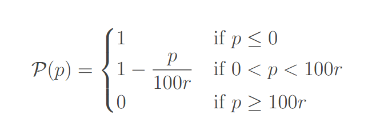

In [442]:
def Precheck_Customers__Percentage_By_Price(price):
    """
    Returns the number of customers that use TSA Precheck as a result of price

    Inputs:
       Price: price of TSA Precheck
    Outputs:
       participation rate: percentage of customers that use TSA Precheck as a result of price
    """

    assumption_dollar_per_percentage = 1.096429 #Calculated from the 30% of travelers at $76.75 dollar cost

    return max(0, min(1, (100 - price/assumption_dollar_per_percentage)/100))


**Run Cost Analysis**

This function runs a series of simulaions for a given price range and returns the results, including total wait time, average wait time, max wait time, throughputs and counts for both screening types.  This then averages across the simulations for the price ranges.

This function will be used to evalute the 3:1 configuration.


In [443]:
def run_cost_analysis(price_range, customer_count, service_params, arrival_rate, num_simulations=10):
    """
    Analyze total wait times across different TSA Precheck prices

    Inputs:
        price_range: list or array of TSA prices to test
        customer_count: total number of customers to simulate
        service_params: dict with service time parameters
        arrival_rate: total arrival rate per minute
        num_simulations: number of simulation runs per price point for averaging

    Outputs:
        results_df: DataFrame with analysis results
    """

    results = []

    for price in price_range:
        print(f"Testing price: ${price}")

        # Run multiple simulations for this price point
        price_results = []

        for sim in range(num_simulations):
            # Calculate demand split
            precheck_percentage = Precheck_Customers__Percentage_By_Price(price)

            # Handle edge cases
            if precheck_percentage <= 0:
                # No one uses precheck - everyone goes to regular line
                standard_customers = customer_count
                precheck_customers = 0
                standard_arrival_rate = arrival_rate
                precheck_arrival_rate = 0
            elif precheck_percentage >= 1:
                # Everyone uses precheck - no one goes to regular line
                standard_customers = 0
                precheck_customers = customer_count
                standard_arrival_rate = 0
                precheck_arrival_rate = arrival_rate
            else:
                # Normal split
                precheck_arrival_rate = arrival_rate * precheck_percentage
                standard_arrival_rate = arrival_rate * (1 - precheck_percentage)
                standard_customers = int((1 - precheck_percentage) * customer_count)
                precheck_customers = int(precheck_percentage * customer_count)

            # Run simulations
            total_wait_time = 0
            total_customers_served = 0

            if standard_customers > 0:
                standard_at, standard_ft, standard_st, standard_wt = Regular_Security_Line(
                    standard_arrival_rate,
                    service_params['regular_mean'],
                    service_params['regular_std'],
                    standard_customers
                )
                total_wait_time += np.sum(standard_wt)
                total_customers_served += standard_customers

            if precheck_customers > 0:
                precheck_at, precheck_ft, precheck_st, precheck_wt = TSA_Precheck_Line(
                    precheck_arrival_rate,
                    service_params['precheck_mean'],
                    service_params['precheck_std'],
                    precheck_customers
                )
                total_wait_time += np.sum(precheck_wt)
                total_customers_served += precheck_customers

            # Calculate metrics for this simulation
            avg_wait_time = total_wait_time / total_customers_served if total_customers_served > 0 else 0

            # Calculate line-specific metrics
            if standard_customers > 0:
                avg_wait_standard = np.mean(standard_wt)
                max_wait_standard = np.max(standard_wt)
                throughput_standard = standard_customers / standard_ft[-1] if len(standard_ft) > 0 else 0
            else:
                avg_wait_standard = 0
                max_wait_standard = 0
                throughput_standard = 0

            if precheck_customers > 0:
                avg_wait_precheck = np.mean(precheck_wt)
                max_wait_precheck = np.max(precheck_wt)
                throughput_precheck = precheck_customers / precheck_ft[-1] if len(precheck_ft) > 0 else 0
            else:
                avg_wait_precheck = 0
                max_wait_precheck = 0
                throughput_precheck = 0

            price_results.append({
                'price': price,
                'precheck_percentage': precheck_percentage,
                'total_wait_time': total_wait_time,
                'avg_wait_time': avg_wait_time,
                'standard_customers': standard_customers,
                'precheck_customers': precheck_customers,
                'avg_wait_standard': avg_wait_standard,
                'avg_wait_precheck': avg_wait_precheck,
                'max_wait_standard': max_wait_standard,
                'max_wait_precheck': max_wait_precheck,
                'throughput_standard': throughput_standard,
                'throughput_precheck': throughput_precheck
            })

        # Average results across simulations for this price
        avg_results = {
            'price': price,
            'precheck_percentage': np.mean([r['precheck_percentage'] for r in price_results]),
            'total_wait_time_mean': np.mean([r['total_wait_time'] for r in price_results]),
            'total_wait_time_std': np.std([r['total_wait_time'] for r in price_results]),
            'avg_wait_time_mean': np.mean([r['avg_wait_time'] for r in price_results]),
            'avg_wait_time_std': np.std([r['avg_wait_time'] for r in price_results]),
            'standard_customers_mean': np.mean([r['standard_customers'] for r in price_results]),
            'precheck_customers_mean': np.mean([r['precheck_customers'] for r in price_results]),
            'avg_wait_standard_mean': np.mean([r['avg_wait_standard'] for r in price_results]),
            'avg_wait_standard_std': np.std([r['avg_wait_standard'] for r in price_results]),
            'avg_wait_precheck_mean': np.mean([r['avg_wait_precheck'] for r in price_results]),
            'avg_wait_precheck_std': np.std([r['avg_wait_precheck'] for r in price_results]),
            'max_wait_standard_mean': np.mean([r['max_wait_standard'] for r in price_results]),
            'max_wait_standard_std': np.std([r['max_wait_standard'] for r in price_results]),
            'max_wait_precheck_mean': np.mean([r['max_wait_precheck'] for r in price_results]),
            'max_wait_precheck_std': np.std([r['max_wait_precheck'] for r in price_results]),
            'throughput_standard_mean': np.mean([r['throughput_standard'] for r in price_results]),
            'throughput_standard_std': np.std([r['throughput_standard'] for r in price_results]),
            'throughput_precheck_mean': np.mean([r['throughput_precheck'] for r in price_results]),
            'throughput_precheck_std': np.std([r['throughput_precheck'] for r in price_results])
        }

        results.append(avg_results)

    return pd.DataFrame(results)

**Run Cost Analysis Split Lanes**

This function runs a series of simulaions for a given price range and returns the results, including total wait time, average wait time, max wait time, throughputs and counts for both screening types.  This then averages across the simulations for the price ranges.

This function will be used to evaulate the 2:2 configuration.


In [444]:
def run_cost_analysis_split_lanes(price_range, customer_count, service_params, arrival_rate, num_simulations=10):
    """
    Analyze total wait times across different TSA Precheck prices

    Inputs:
        price_range: list or array of TSA prices to test
        customer_count: total number of customers to simulate
        service_params: dict with service time parameters
        arrival_rate: total arrival rate per minute
        num_simulations: number of simulation runs per price point for averaging

    Outputs:
        results_df: DataFrame with analysis results
    """

    results = []

    for price in price_range:
        print(f"Testing price: ${price}")

        # Run multiple simulations for this price point
        price_results = []

        for sim in range(num_simulations):
            # Calculate demand split
            precheck_percentage = Precheck_Customers__Percentage_By_Price(price)

            # Handle edge cases
            if precheck_percentage <= 0:
                # No one uses precheck - everyone goes to regular line
                standard_customers = customer_count
                precheck_customers = 0
                standard_arrival_rate = arrival_rate
                precheck_arrival_rate = 0
            elif precheck_percentage >= 1:
                # Everyone uses precheck - no one goes to regular line
                standard_customers = 0
                precheck_customers = customer_count
                standard_arrival_rate = 0
                precheck_arrival_rate = arrival_rate
            else:
                # Normal split
                precheck_arrival_rate = arrival_rate * precheck_percentage
                standard_arrival_rate = arrival_rate * (1 - precheck_percentage)
                standard_customers = int((1 - precheck_percentage) * customer_count)
                precheck_customers = int(precheck_percentage * customer_count)

            # Run simulations
            total_wait_time = 0
            total_customers_served = 0

            if standard_customers > 0:
                standard_at, standard_ft, standard_st, standard_wt = Two_Lane_Security(
                    standard_arrival_rate,
                    service_params['regular_mean'],
                    service_params['regular_std'],
                    standard_customers
                )
                total_wait_time += np.sum(standard_wt)
                total_customers_served += standard_customers

            if precheck_customers > 0:
                precheck_at, precheck_ft, precheck_st, precheck_wt = Two_Lane_Security(
                    precheck_arrival_rate,
                    service_params['precheck_mean'],
                    service_params['precheck_std'],
                    precheck_customers
                )
                total_wait_time += np.sum(precheck_wt)
                total_customers_served += precheck_customers

            # Calculate metrics for this simulation
            avg_wait_time = total_wait_time / total_customers_served if total_customers_served > 0 else 0

            # Calculate line-specific metrics
            if standard_customers > 0:
                avg_wait_standard = np.mean(standard_wt)
                max_wait_standard = np.max(standard_wt)
                throughput_standard = standard_customers / standard_ft[-1] if len(standard_ft) > 0 else 0
            else:
                avg_wait_standard = 0
                max_wait_standard = 0
                throughput_standard = 0

            if precheck_customers > 0:
                avg_wait_precheck = np.mean(precheck_wt)
                max_wait_precheck = np.max(precheck_wt)
                throughput_precheck = precheck_customers / precheck_ft[-1] if len(precheck_ft) > 0 else 0
            else:
                avg_wait_precheck = 0
                max_wait_precheck = 0
                throughput_precheck = 0

            price_results.append({
                'price': price,
                'precheck_percentage': precheck_percentage,
                'total_wait_time': total_wait_time,
                'avg_wait_time': avg_wait_time,
                'standard_customers': standard_customers,
                'precheck_customers': precheck_customers,
                'avg_wait_standard': avg_wait_standard,
                'avg_wait_precheck': avg_wait_precheck,
                'max_wait_standard': max_wait_standard,
                'max_wait_precheck': max_wait_precheck,
                'throughput_standard': throughput_standard,
                'throughput_precheck': throughput_precheck
            })

        # Average results across simulations for this price
        avg_results = {
            'price': price,
            'precheck_percentage': np.mean([r['precheck_percentage'] for r in price_results]),
            'total_wait_time_mean': np.mean([r['total_wait_time'] for r in price_results]),
            'total_wait_time_std': np.std([r['total_wait_time'] for r in price_results]),
            'avg_wait_time_mean': np.mean([r['avg_wait_time'] for r in price_results]),
            'avg_wait_time_std': np.std([r['avg_wait_time'] for r in price_results]),
            'standard_customers_mean': np.mean([r['standard_customers'] for r in price_results]),
            'precheck_customers_mean': np.mean([r['precheck_customers'] for r in price_results]),
            'avg_wait_standard_mean': np.mean([r['avg_wait_standard'] for r in price_results]),
            'avg_wait_standard_std': np.std([r['avg_wait_standard'] for r in price_results]),
            'avg_wait_precheck_mean': np.mean([r['avg_wait_precheck'] for r in price_results]),
            'avg_wait_precheck_std': np.std([r['avg_wait_precheck'] for r in price_results]),
            'max_wait_standard_mean': np.mean([r['max_wait_standard'] for r in price_results]),
            'max_wait_standard_std': np.std([r['max_wait_standard'] for r in price_results]),
            'max_wait_precheck_mean': np.mean([r['max_wait_precheck'] for r in price_results]),
            'max_wait_precheck_std': np.std([r['max_wait_precheck'] for r in price_results]),
            'throughput_standard_mean': np.mean([r['throughput_standard'] for r in price_results]),
            'throughput_standard_std': np.std([r['throughput_standard'] for r in price_results]),
            'throughput_precheck_mean': np.mean([r['throughput_precheck'] for r in price_results]),
            'throughput_precheck_std': np.std([r['throughput_precheck'] for r in price_results])
        }

        results.append(avg_results)

    return pd.DataFrame(results)

**Plot Results Function**

This function takes teh results from cost analysis functions and plots them.

In [445]:
def plot_results(results_df):
    """
    Create visualizations of the cost analysis results
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 15))

    # Plot 1: Total Wait Time vs Price
    ax1.errorbar(results_df['price'], results_df['total_wait_time_mean'],
                yerr=results_df['total_wait_time_std'], marker='o', capsize=5)
    ax1.set_xlabel('TSA Precheck Price ($)')
    ax1.set_ylabel('Total Wait Time (minutes)')
    ax1.set_title('Total System Wait Time vs TSA Price')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Average Wait Time vs Price (Line-Specific)
    ax2.errorbar(results_df['price'], results_df['avg_wait_standard_mean'],
                yerr=results_df['avg_wait_standard_std'], marker='o', capsize=5,
                color='red', label='Regular Security')
    ax2.errorbar(results_df['price'], results_df['avg_wait_precheck_mean'],
                yerr=results_df['avg_wait_precheck_std'], marker='s', capsize=5,
                color='blue', label='TSA Precheck')
    ax2.set_xlabel('TSA Precheck Price ($)')
    ax2.set_ylabel('Average Wait Time (minutes)')
    ax2.set_title('Average Wait Time by Screening Type')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Maximum Wait Times
    ax3.errorbar(results_df['price'], results_df['max_wait_standard_mean'],
                yerr=results_df['max_wait_standard_std'], marker='o', capsize=5,
                color='red', label='Regular Security')
    ax3.errorbar(results_df['price'], results_df['max_wait_precheck_mean'],
                yerr=results_df['max_wait_precheck_std'], marker='s', capsize=5,
                color='blue', label='TSA Precheck')
    ax3.set_xlabel('TSA Precheck Price ($)')
    ax3.set_ylabel('Maximum Wait Time (minutes)')
    ax3.set_title('Maximum Wait Time by Screening Type')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Throughput (Passengers per Minute)
    ax4.errorbar(results_df['price'], results_df['throughput_standard_mean'],
                yerr=results_df['throughput_standard_std'], marker='o', capsize=5,
                color='red', label='Regular Security')
    ax4.errorbar(results_df['price'], results_df['throughput_precheck_mean'],
                yerr=results_df['throughput_precheck_std'], marker='s', capsize=5,
                color='blue', label='TSA Precheck')
    ax4.set_xlabel('TSA Precheck Price ($)')
    ax4.set_ylabel('Throughput (passengers/minute)')
    ax4.set_title('Screening Throughput by Type')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

**Print Results**

This function takes the results and prints them out for reading.

In [446]:
def print_results(wait_times_precheck, wait_times_regular):
    """Print simulation results"""
    print(f"TSA PreCheck:")
    print(
        f"  Average wait time: {sum(wait_times_precheck) / len(wait_times_precheck):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_precheck)):.2f}")
    print(f"  Max wait time: {max(wait_times_precheck):.2f}")

    print(f"\nRegular Passengers:")
    print(
        f"  Average wait time: {sum(wait_times_regular) / len(wait_times_regular):.2f}"
    )
    print(f"  Variance of wait times: {np.var(list(wait_times_regular)):.2f}")
    print(f"  Max wait time: {max(wait_times_regular):.2f}")

# Single Checkpoint Variable Values

In order to generate normal values, we need to convert from a service rate to the individuals service time.  We additionally need standard deviations to evaluate.  

Standard screening service time per person calulated by dividing 1 by the standard screening service rate.

Service time standard deviation is an assumption, set at 0.2

In [447]:
SERVICE_TIME_REGULAR_SECURITY = 1/SERVICE_RATE_REGULAR
SERVICE_TIME_REGULAR_SECURITY_STD =0.2

print("Standard Screening Service Time Average: " + str(SERVICE_TIME_REGULAR_SECURITY))
print("Standard Screening Service Time Standard Deviation: " + str(SERVICE_TIME_REGULAR_SECURITY_STD))

Standard Screening Service Time Average: 0.5075884472869397
Standard Screening Service Time Standard Deviation: 0.2


PreCheck service time per person calulated by dividing 1 by the service rate.

Precheck service time standard deviation is an assumption, set at 0.1

In [448]:
SERVICE_TIME_PSA_PRECHECK = 1/SERVICE_RATE_PRECHECK
SERVICE_TIME_PSA_PRECHECK_STD = 0.1
print("PreCheck Screening Service Time Average: " + str(SERVICE_TIME_PSA_PRECHECK))
print("PreCheck Screening Service Time Standard Deviation: " + str(SERVICE_TIME_PSA_PRECHECK_STD))

PreCheck Screening Service Time Average: 0.3816454490879246
PreCheck Screening Service Time Standard Deviation: 0.1


Total arrivals scaled down from 12 server simulation to 4 server simulation

In [449]:
SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE = ARRIVAL_RATE/3
print("Average arrival rate per minute: " + str(SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE))

Average arrival rate per minute: 7.866666666666667


TSA Current cost from :https://tsaenrollmentbyidemia.tsa.dhs.gov/programs/precheck

In [465]:
TSA_PRECHECK_CURRENT_COST = 76.75
print("Current TSA PreCheck Cost: " + str(TSA_PRECHECK_CURRENT_COST))

Current TSA PreCheck Cost: 76.75


#Experiments

## Confirm Code Functionality

Confirm TSA pricing and partcipiation values.

In [479]:
print("TSA Participation at current cost : "+str(Precheck_Customers__Percentage_By_Price(TSA_PRECHECK_CURRENT_COST)))

TSA Participation at current cost : 0.3000002736155282


Validating that the code works as expected below.

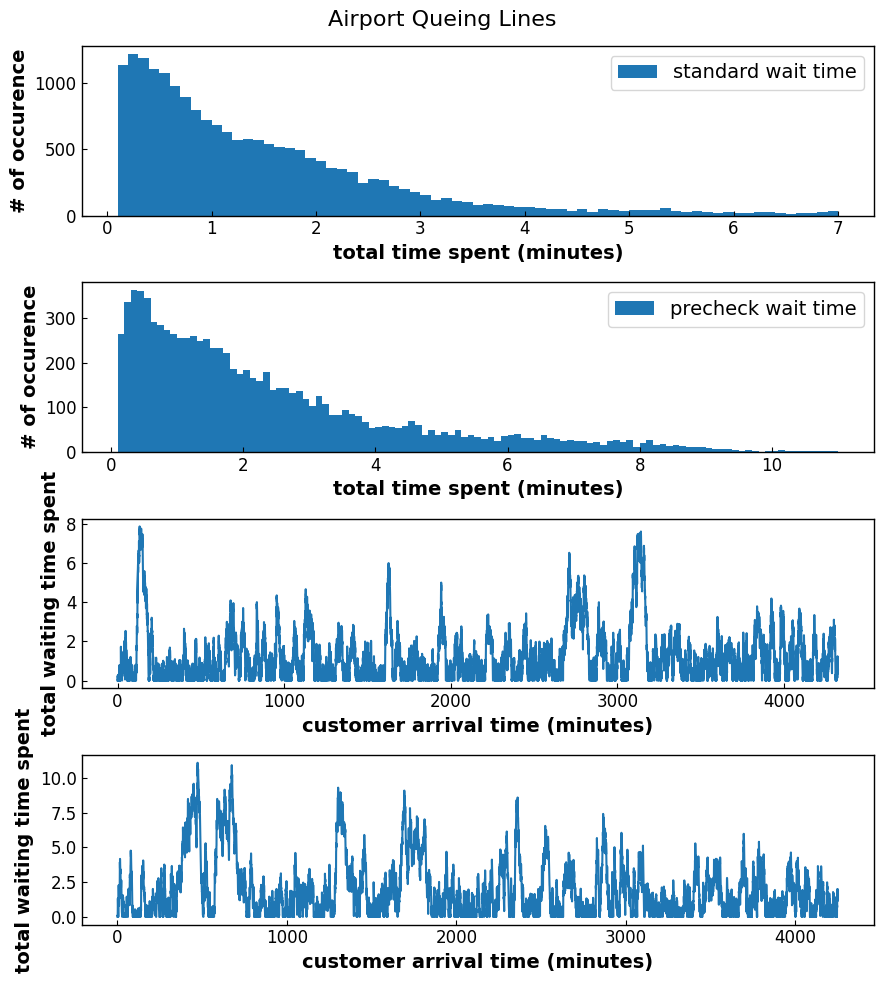

In [480]:
# Set seed for reproduceability.
np.random.seed(100)


# Set customer count and tsa precheck cost.
customer_count = MAX_CUST
tsa_precheck_cost= TSA_PRECHECK_CURRENT_COST



precheck_percentage = Precheck_Customers__Percentage_By_Price(tsa_precheck_cost)

precheck_arrival_rate=SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE*precheck_percentage
standard_arrival_rate=SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE*(1-precheck_percentage)

standard_at, standard_ft, standard_st, standard_wt = Regular_Security_Line(standard_arrival_rate, SERVICE_TIME_REGULAR_SECURITY, SERVICE_TIME_REGULAR_SECURITY_STD, int((1-precheck_percentage)*customer_count))
precheck_at, precheck_ft, precheck_st, precheck_wt = TSA_Precheck_Line(precheck_arrival_rate, SERVICE_TIME_PSA_PRECHECK, SERVICE_TIME_PSA_PRECHECK_STD, int((precheck_percentage)*customer_count))

# Compare simulation to Poisson distribution
fig, axs = plt.subplots(4, 1, figsize=(9, 10), tight_layout=True)

bin_size = .1

# Plot histogram of waiting times
axs[0].hist(
    standard_wt,
    bins=np.arange(.1, np.floor(np.max(standard_wt)) + bin_size, bin_size),
    label="standard wait time",
)
axs[0].set(ylabel="# of occurence")
axs[0].set(xlabel="total time spent (minutes)")

# Plot histogram of waiting times
axs[1].hist(
    precheck_wt,
    bins=np.arange(.1, np.floor(np.max(precheck_wt)) + bin_size, bin_size),
    label="precheck wait time",
)
axs[1].set(ylabel="# of occurence")
axs[1].set(xlabel="total time spent (minutes)")


# Plot total wait time
axs[2].plot(standard_at, standard_wt)
axs[2].set(xlabel="customer arrival time (minutes)")
axs[2].set(ylabel="total waiting time spent")

# Plot total wait time
axs[3].plot(precheck_at, precheck_wt)
axs[3].set(xlabel="customer arrival time (minutes)")
axs[3].set(ylabel="total waiting time spent")

# make legend
axs[0].legend()
axs[1].legend()
plt.suptitle("Airport Queing Lines", fontsize=16)
plt.show()

## 3:1 Configuration Price Finding and Simulation

Now we run the price ranging simulation to identify the optimal price, using $10 increments to speed up the simulation.

Running TSA cost analysis...
Testing price: $0
Testing price: $10
Testing price: $20
Testing price: $30
Testing price: $40
Testing price: $50
Testing price: $60
Testing price: $70
Testing price: $80
Testing price: $90
Testing price: $100
Testing price: $110

Results Summary:
    price  precheck_percentage  total_wait_time_mean  avg_wait_time_mean
0       0                1.000          1.474376e+08            4336.399
1      10                0.909          1.152130e+08            3388.716
2      20                0.818          8.702382e+07            2559.599
3      30                0.726          6.297804e+07            1852.350
4      40                0.635          4.257350e+07            1252.198
5      50                0.544          2.517822e+07             740.558
6      60                0.453          1.224297e+07             360.098
7      70                0.362          2.194691e+06              64.552
8      80                0.270          8.766609e+04               

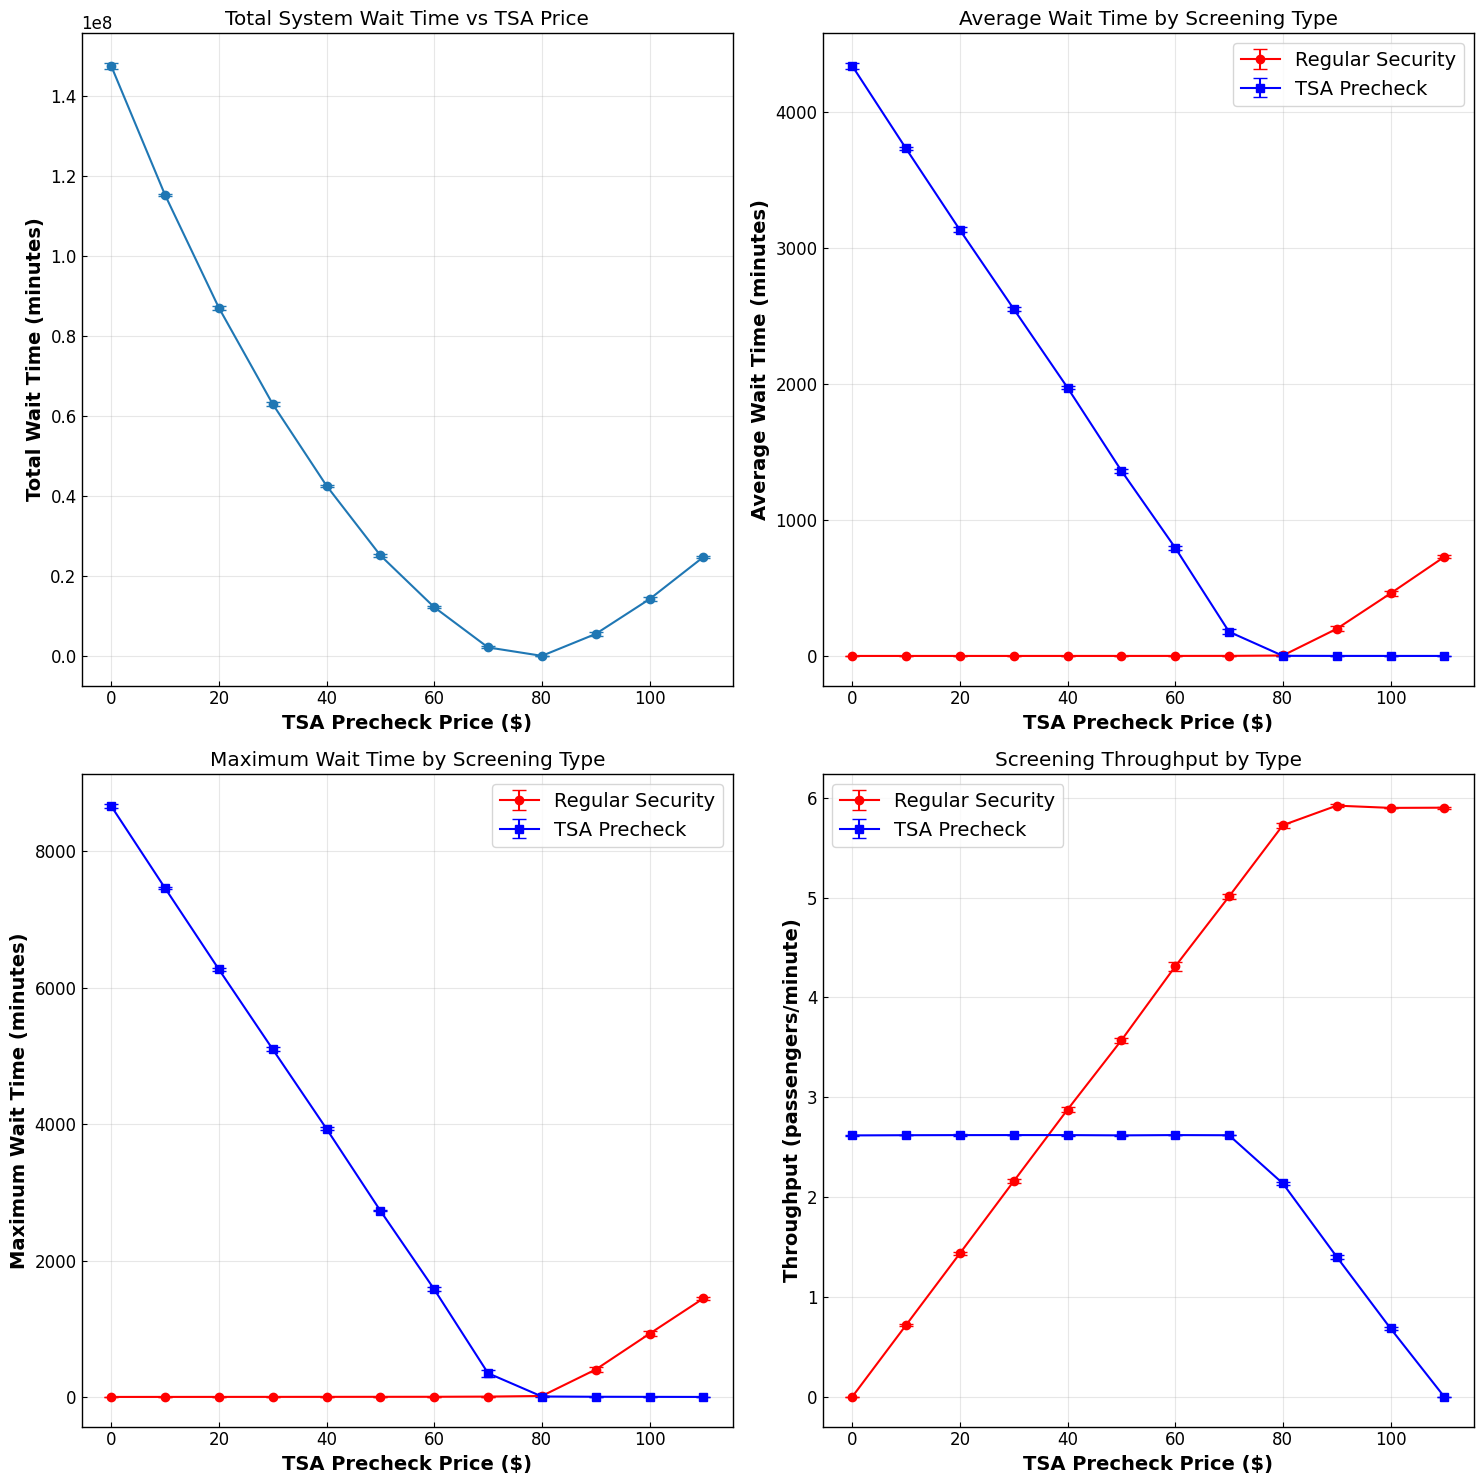

In [481]:
# Set seed for reproduceability.
np.random.seed(100)

# Define test parameters
price_range = np.arange(0, 120, 10)  # Test prices from $0 to $110 in $10 increments
customer_count = MAX_CUST

service_params = {
    'regular_mean': SERVICE_TIME_REGULAR_SECURITY,
    'regular_std': SERVICE_TIME_REGULAR_SECURITY_STD,
    'precheck_mean': SERVICE_TIME_PSA_PRECHECK,
    'precheck_std': SERVICE_TIME_PSA_PRECHECK_STD
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=customer_count,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=5  # Run 5 simulations per price point
)

# Display results
print("\nResults Summary:")
print(results[['price', 'precheck_percentage', 'total_wait_time_mean', 'avg_wait_time_mean']].round(3))

# Find optimal price (minimum total wait time)
optimal_idx = results['total_wait_time_mean'].idxmin()
optimal_price = results.loc[optimal_idx, 'price']
optimal_wait_time = results.loc[optimal_idx, 'total_wait_time_mean']

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%")

# Create visualizations
plot_results(results)


So now we know that the optimal price is in the range 70 to 90, so we tighten our price range and lower the increment to $0.25 to evaluate.

Running TSA cost analysis...
Testing price: $70.0
Testing price: $70.25
Testing price: $70.5
Testing price: $70.75
Testing price: $71.0
Testing price: $71.25
Testing price: $71.5
Testing price: $71.75
Testing price: $72.0
Testing price: $72.25
Testing price: $72.5
Testing price: $72.75
Testing price: $73.0
Testing price: $73.25
Testing price: $73.5
Testing price: $73.75
Testing price: $74.0
Testing price: $74.25
Testing price: $74.5
Testing price: $74.75
Testing price: $75.0
Testing price: $75.25
Testing price: $75.5
Testing price: $75.75
Testing price: $76.0
Testing price: $76.25
Testing price: $76.5
Testing price: $76.75
Testing price: $77.0
Testing price: $77.25
Testing price: $77.5
Testing price: $77.75
Testing price: $78.0
Testing price: $78.25
Testing price: $78.5
Testing price: $78.75
Testing price: $79.0
Testing price: $79.25
Testing price: $79.5
Testing price: $79.75
Testing price: $80.0
Testing price: $80.25
Testing price: $80.5
Testing price: $80.75
Testing price: $81.0
Test

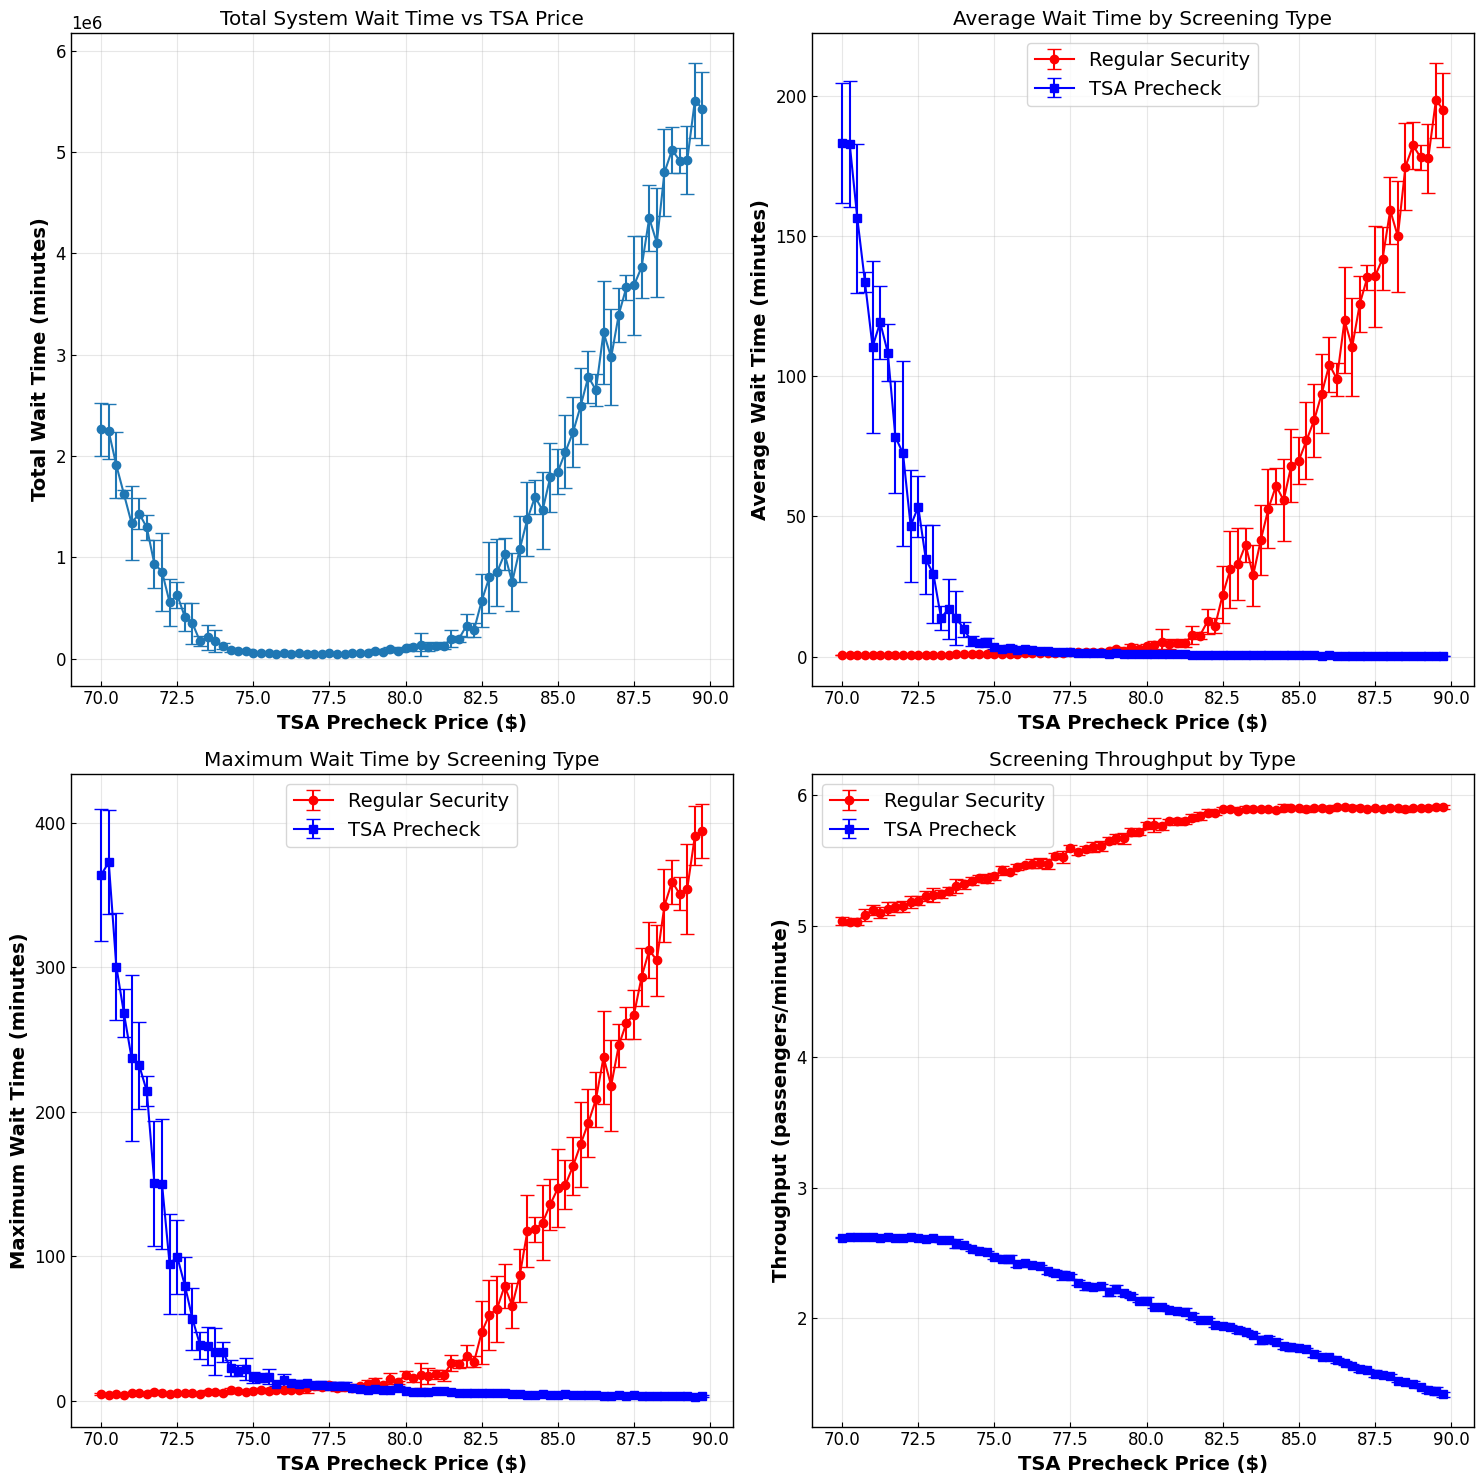

In [482]:
# Putting in Seed value for repeatability.
np.random.seed(100)

# Define test parameters
price_range = np.arange(70, 90, 0.25)  # Test prices from $0 to $110 in $10 increments
customer_count = MAX_CUST

service_params = {
    'regular_mean': SERVICE_TIME_REGULAR_SECURITY,
    'regular_std': SERVICE_TIME_REGULAR_SECURITY_STD,
    'precheck_mean': SERVICE_TIME_PSA_PRECHECK,
    'precheck_std': SERVICE_TIME_PSA_PRECHECK_STD
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=customer_count,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=5  # Run 10 simulations per price point
)

# Display results
print("\nResults Summary:")
print(results[['price', 'precheck_percentage', 'total_wait_time_mean', 'avg_wait_time_mean']].round(3))

# Find optimal price (minimum total wait time)
optimal_idx = results['total_wait_time_mean'].idxmin()
optimal_price = results.loc[optimal_idx, 'price']
optimal_wait_time = results.loc[optimal_idx, 'total_wait_time_mean']

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%")

# Create visualizations
plot_results(results)


After iterating through this a couple times without a seed, the values fluctuate between 76.25 and 77.25.  This is due to the probabilistic nature of the model.  The midpoint of this is $76.75, which turns out to be the current TSA cost.  With the seed selected, this is the value that we observe.

In [483]:
# Putting in seed value for repeatability.
np.random.seed(100)


# Define test parameters
price_range = [76.75]

service_params = {
    'regular_mean': SERVICE_TIME_REGULAR_SECURITY,
    'regular_std': SERVICE_TIME_REGULAR_SECURITY_STD,
    'precheck_mean': SERVICE_TIME_PSA_PRECHECK,
    'precheck_std': SERVICE_TIME_PSA_PRECHECK_STD
}

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=MAX_CUST,
    service_params=service_params,
    arrival_rate=SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE,
    num_simulations=500  # Run 500 simulations per price point
)

print(results)

Running TSA cost analysis...
Testing price: $76.75
   price  precheck_percentage  total_wait_time_mean  total_wait_time_std  \
0  76.75                  0.3          49200.571243          5536.498094   

   avg_wait_time_mean  avg_wait_time_std  standard_customers_mean  \
0            1.447118           0.162843                  23799.0   

   precheck_customers_mean  avg_wait_standard_mean  avg_wait_standard_std  \
0                  10200.0                1.288497               0.202373   

   avg_wait_precheck_mean  avg_wait_precheck_std  max_wait_standard_mean  \
0                1.817219               0.266484                8.294574   

   max_wait_standard_std  max_wait_precheck_mean  max_wait_precheck_std  \
0               1.857322               11.225911               2.351299   

   throughput_standard_mean  throughput_standard_std  \
0                   5.50288                 0.035486   

   throughput_precheck_mean  throughput_precheck_std  
0                  2.357172   

In [484]:
print("Average Wait Time Standard Screening: " + str(results['avg_wait_standard_mean'].values[0]))
print("Average Wait Time PreCheck Screening: " + str(results['avg_wait_precheck_mean'].values[0]))
print("Average Max Wait Time Standard Screening: " + str(results['max_wait_standard_mean'].values[0]))
print("Average Max Wait Time PreCheck Screening: " + str(results['max_wait_precheck_mean'].values[0]))
print("Average Throughput Standard Screening: " + str(results['throughput_standard_mean'].values[0]))
print("Average Throughput Standard Screening per Server: " + str(results['throughput_standard_mean'].values[0]/3))
print("Average Throughput PreCheck Screening: " + str(results['throughput_precheck_mean'].values[0]))


Average Wait Time Standard Screening: 1.288496894202561
Average Wait Time PreCheck Screening: 1.817218986098972
Average Max Wait Time Standard Screening: 8.29457376575208
Average Max Wait Time PreCheck Screening: 11.225911085142576
Average Throughput Standard Screening: 5.50288049250012
Average Throughput Standard Screening per Server: 1.83429349750004
Average Throughput PreCheck Screening: 2.3571720226079416


These results are slightly counter-intuitive, as we would expect the PreCheck line to have lower average wait times and lower maximum wait time.  We attribute this to the server distribution creating a bottleneck for the PreCheck.  The intuitive part of the result is that although the Standrad Screening Throughput is higher, when evaluated on a per server basis, we observe a higher rate for the PreCheck Lane then for the standard screening lane.

## 70% TSA PreCheck Participation in 3:1

Now lets investigate what would happen if the participation percentage increases to 70%.  From the demand model, we know that 70% occurs at approximatlye $32.89.

In [485]:
print(Precheck_Customers__Percentage_By_Price(32.892))

0.7000079348503186


Now, lets evaluate what happens in the current 3:1 configuration if the participation increases to 70%, inline with the TSA's goal per the washington post: https://www.washingtonpost.com/travel/2024/11/28/tsa-precheck-vs-standard-security-line/

In [486]:
# Putting in Seed value for repeatability.
np.random.seed(100)

customer_count = 34000

# Define test parameters
price_range = [32.89]

service_params = {
    'regular_mean': SERVICE_TIME_REGULAR_SECURITY,
    'regular_std': SERVICE_TIME_REGULAR_SECURITY_STD,
    'precheck_mean': SERVICE_TIME_PSA_PRECHECK,
    'precheck_std': SERVICE_TIME_PSA_PRECHECK_STD
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis(
    price_range=price_range,
    customer_count=customer_count,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=500  # Run 500 simulations per price point
)

print(results)

Running TSA cost analysis...
Testing price: $32.89
   price  precheck_percentage  total_wait_time_mean  total_wait_time_std  \
0  32.89             0.700026          5.668803e+07        448732.013687   

   avg_wait_time_mean  avg_wait_time_std  standard_customers_mean  \
0         1667.343998          13.198389                  10199.0   

   precheck_customers_mean  avg_wait_standard_mean  avg_wait_standard_std  \
0                  23800.0                 0.02562               0.001774   

   avg_wait_precheck_mean  avg_wait_precheck_std  max_wait_standard_mean  \
0             2381.838962              18.854226                0.992761   

   max_wait_standard_std  max_wait_precheck_mean  max_wait_precheck_std  \
0               0.150854             4763.069417              32.538446   

   throughput_standard_mean  throughput_standard_std  \
0                  2.358621                 0.023755   

   throughput_precheck_mean  throughput_precheck_std  
0                  2.620386   

In [487]:
print("Average Wait Time Standard Screening: " + str(results['avg_wait_standard_mean'].values[0]))
print("Average Wait Time PreCheck Screening: " + str(results['avg_wait_precheck_mean'].values[0]))
print("Average Max Wait Time Standard Screening: " + str(results['max_wait_standard_mean'].values[0]))
print("Average Max Wait Time PreCheck Screening: " + str(results['max_wait_precheck_mean'].values[0]))
print("Average Throughput Standard Screening: " + str(results['throughput_standard_mean'].values[0]))
print("Average Throughput Standard Screening per Server: " + str(results['throughput_standard_mean'].values[0]/3))
print("Average Throughput PreCheck Screening: " + str(results['throughput_precheck_mean'].values[0]))


Average Wait Time Standard Screening: 0.025620176747462992
Average Wait Time PreCheck Screening: 2381.8389622704135
Average Max Wait Time Standard Screening: 0.9927608936849152
Average Max Wait Time PreCheck Screening: 4763.06941682276
Average Throughput Standard Screening: 2.3586212909100768
Average Throughput Standard Screening per Server: 0.7862070969700256
Average Throughput PreCheck Screening: 2.6203862764294654


From this evaluation, we see that this leads to an unrealistic model.  The average TSA precheck passenger will wait 2381 minutes, or 1.65 days in line.  This is an inefficient use of resources and not a sustainable approach.

## Reassignment to a 2:2 Configuration

Now we reconfigure so that the servers are split evenly between the two screening types.  We use the "run_cost_anlysis_split_lanes" function to do this evaluation.

Running TSA cost analysis...
Testing price: $0
Testing price: $10
Testing price: $20
Testing price: $30
Testing price: $40
Testing price: $50
Testing price: $60
Testing price: $70
Testing price: $80
Testing price: $90
Testing price: $100
Testing price: $110

Results Summary:
    price  precheck_percentage  total_wait_time_mean  avg_wait_time_mean  \
0       0                1.000          3.708220e+07            1090.653   
1      10                0.909          2.415487e+07             710.458   
2      20                0.818          1.334013e+07             392.368   
3      30                0.726          4.847019e+06             142.564   
4      40                0.635          5.012468e+04               1.474   
5      50                0.544          3.100121e+04               0.912   
6      60                0.453          3.741566e+06             110.049   
7      70                0.362          1.277125e+07             375.636   
8      80                0.270          

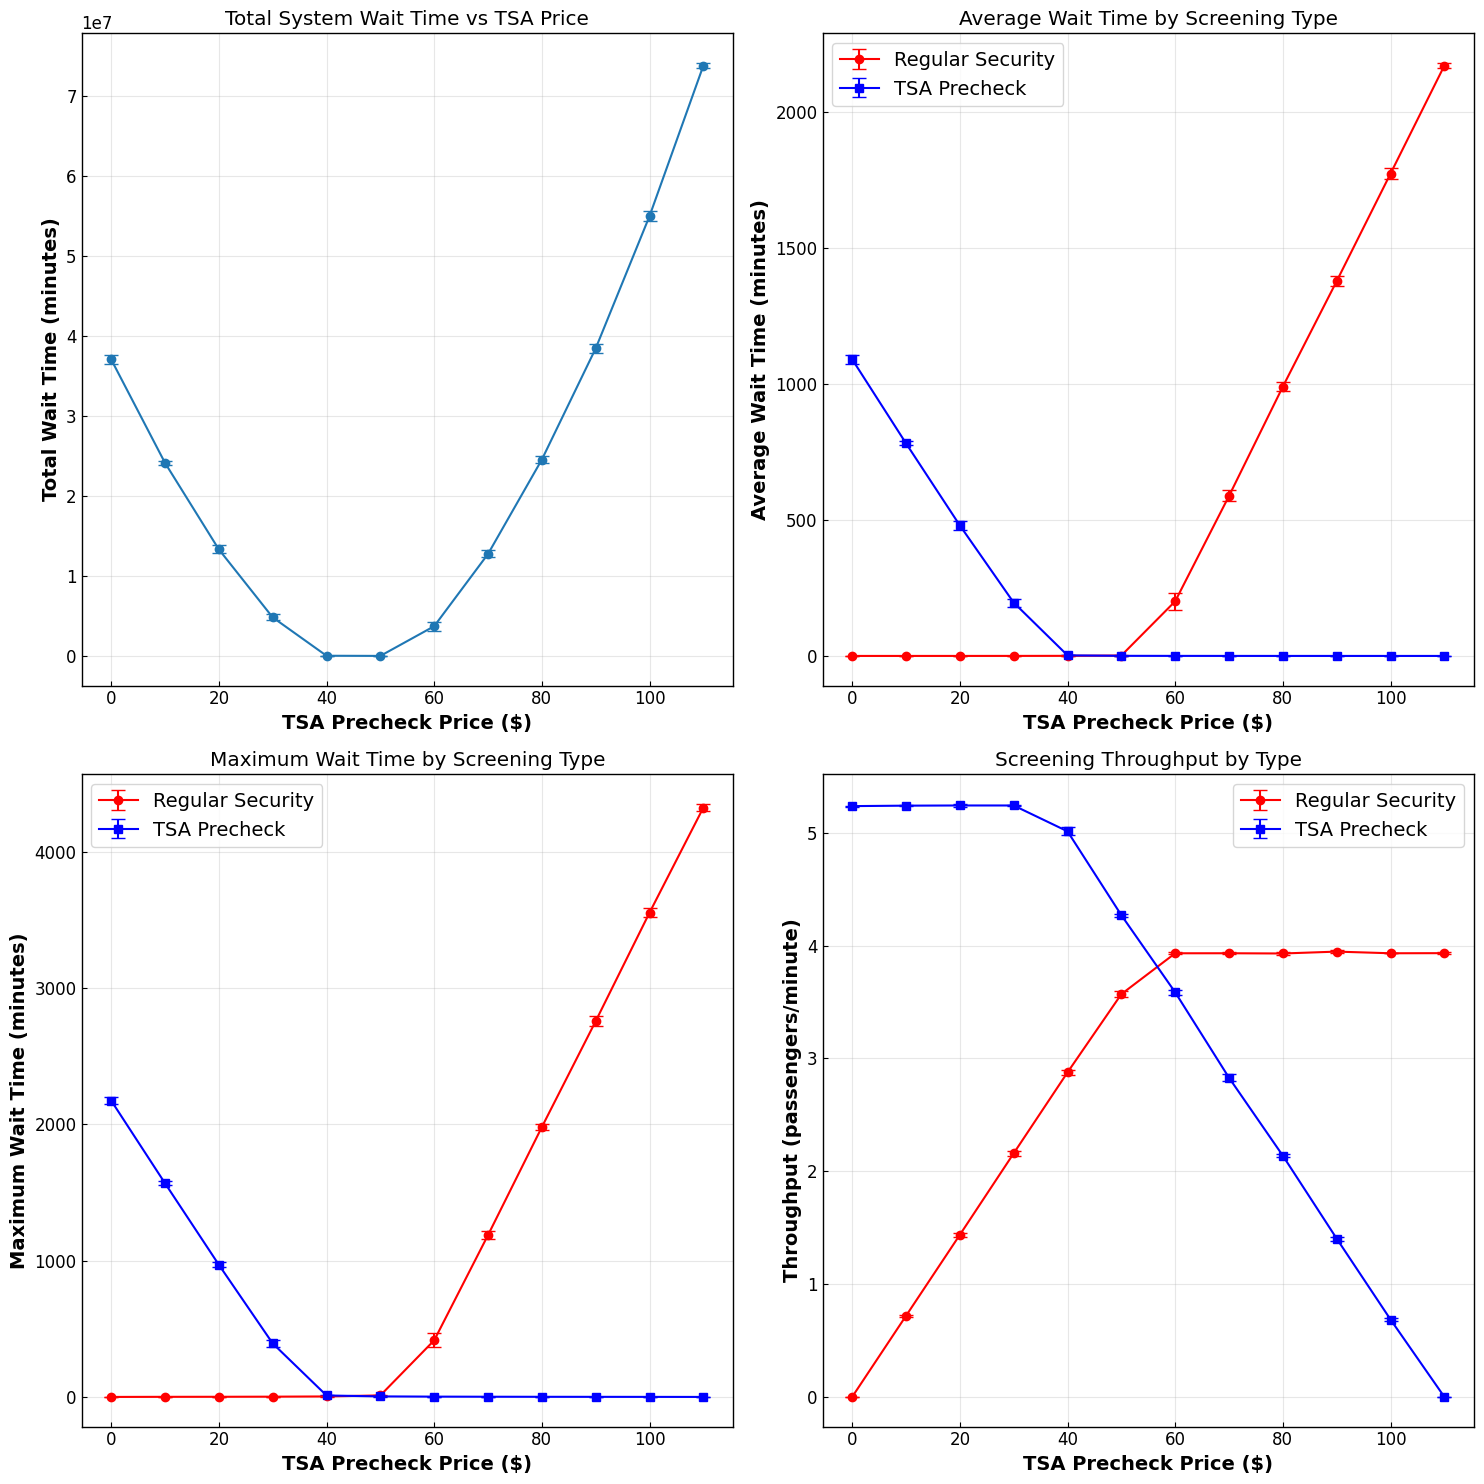

In [488]:
# Putting in seed value for repeatability.
np.random.seed(100)

# Define test parameters
price_range = np.arange(0, 120, 10)  # Test prices from $0 to $110 in $10 increments

service_params = {
    'regular_mean': SERVICE_TIME_REGULAR_SECURITY,
    'regular_std': SERVICE_TIME_REGULAR_SECURITY_STD,
    'precheck_mean': SERVICE_TIME_PSA_PRECHECK,
    'precheck_std': SERVICE_TIME_PSA_PRECHECK_STD
}

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis_split_lanes(
    price_range=price_range,
    customer_count=MAX_CUST,
    service_params=service_params,
    arrival_rate=SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE,
    num_simulations=5  # Run 5 simulations per price point
)

# Display results
print("\nResults Summary:")
print(results[['price', 'precheck_percentage', 'total_wait_time_mean', 'avg_wait_time_mean',
                'avg_wait_standard_mean', 'avg_wait_precheck_mean',
                'throughput_standard_mean', 'throughput_precheck_mean']].round(3))

# Find optimal price (minimum total wait time)
optimal_idx = results['total_wait_time_mean'].idxmin()
optimal_price = results.loc[optimal_idx, 'price']
optimal_wait_time = results.loc[optimal_idx, 'total_wait_time_mean']

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%")

# Create visualizations
plot_results(results)

From this initial price range, we see that the point of interests are between the high 30's and the low 50's, so we tighten the range and lower the step size to 0.25.

Running TSA cost analysis...
Testing price: $38.0
Testing price: $38.25
Testing price: $38.5
Testing price: $38.75
Testing price: $39.0
Testing price: $39.25
Testing price: $39.5
Testing price: $39.75
Testing price: $40.0
Testing price: $40.25
Testing price: $40.5
Testing price: $40.75
Testing price: $41.0
Testing price: $41.25
Testing price: $41.5
Testing price: $41.75
Testing price: $42.0
Testing price: $42.25
Testing price: $42.5
Testing price: $42.75
Testing price: $43.0
Testing price: $43.25
Testing price: $43.5
Testing price: $43.75
Testing price: $44.0
Testing price: $44.25
Testing price: $44.5
Testing price: $44.75
Testing price: $45.0
Testing price: $45.25
Testing price: $45.5
Testing price: $45.75
Testing price: $46.0
Testing price: $46.25
Testing price: $46.5
Testing price: $46.75
Testing price: $47.0
Testing price: $47.25
Testing price: $47.5
Testing price: $47.75
Testing price: $48.0
Testing price: $48.25
Testing price: $48.5
Testing price: $48.75
Testing price: $49.0
Test

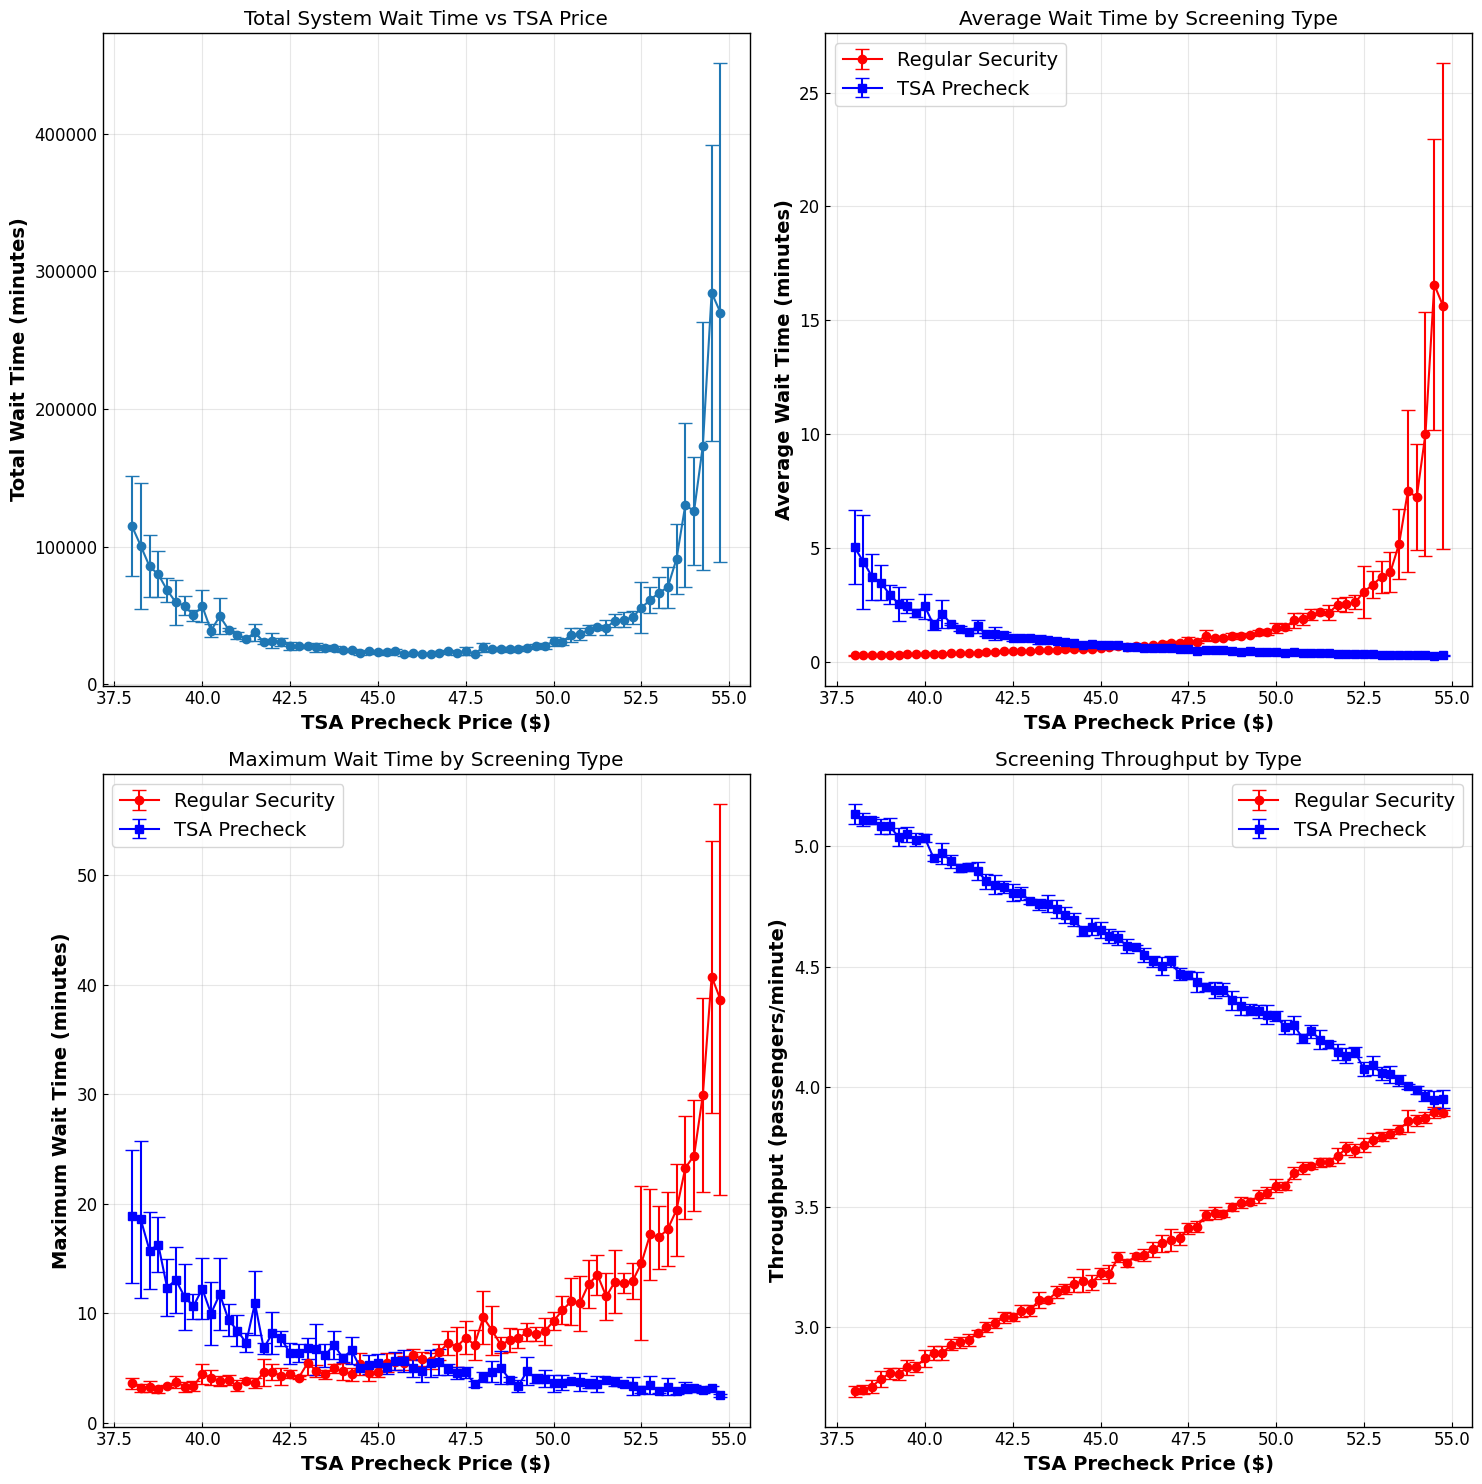

In [489]:
# Putting in seed value for repeatability.
np.random.seed(100)

# Define test parameters
price_range = np.arange(38, 55, .25)  # Test prices from $0 to $110 in $10 increments

service_params = {
    'regular_mean': SERVICE_TIME_REGULAR_SECURITY,
    'regular_std': SERVICE_TIME_REGULAR_SECURITY_STD,
    'precheck_mean': SERVICE_TIME_PSA_PRECHECK,
    'precheck_std': SERVICE_TIME_PSA_PRECHECK_STD
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis_split_lanes(
    price_range=price_range,
    customer_count=MAX_CUST,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=5  # Run 5 simulations per price point
)

# Display results
print("\nResults Summary:")
print(results[['price', 'precheck_percentage', 'total_wait_time_mean', 'avg_wait_time_mean',
                'avg_wait_standard_mean', 'avg_wait_precheck_mean',
                'throughput_standard_mean', 'throughput_precheck_mean']].round(3))

# Find optimal price (minimum total wait time)
optimal_idx = results['total_wait_time_mean'].idxmin()
optimal_price = results.loc[optimal_idx, 'price']
optimal_wait_time = results.loc[optimal_idx, 'total_wait_time_mean']

print(f"\nOptimal TSA Price: ${optimal_price}")
print(f"Total Wait Time at Optimal Price: {optimal_wait_time:.2f} minutes")
print(f"Precheck Adoption at Optimal Price: {results.loc[optimal_idx, 'precheck_percentage']*100:.1f}%")

# Create visualizations
plot_results(results)

We observe that the optimal TSA price is at $46.50.  With that information, we rerun the evaluation to find statistics on this price scenario.

In [490]:
# Putting in seed value for repeatability.
np.random.seed(100)


# Define test parameters
price_range = [46.5]

service_params = {
    'regular_mean': SERVICE_TIME_REGULAR_SECURITY,
    'regular_std': SERVICE_TIME_REGULAR_SECURITY_STD,
    'precheck_mean': SERVICE_TIME_PSA_PRECHECK,
    'precheck_std': SERVICE_TIME_PSA_PRECHECK_STD
}

total_arrival_rate_per_minute = SINGLE_CHECKPOINT_ARRIVAL_RATE_PER_MINUTE

# Run the analysis
print("Running TSA cost analysis...")
results = run_cost_analysis_split_lanes(
    price_range=price_range,
    customer_count=MAX_CUST,
    service_params=service_params,
    arrival_rate=total_arrival_rate_per_minute,
    num_simulations=500  # Run 500 simulations per price point
)

print(results)

Running TSA cost analysis...
Testing price: $46.5
   price  precheck_percentage  total_wait_time_mean  total_wait_time_std  \
0   46.5             0.575896          22892.629034          1469.106276   

   avg_wait_time_mean  avg_wait_time_std  standard_customers_mean  \
0            0.673332            0.04321                  14419.0   

   precheck_customers_mean  avg_wait_standard_mean  avg_wait_standard_std  \
0                  19580.0                0.756697               0.074234   

   avg_wait_precheck_mean  avg_wait_precheck_std  max_wait_standard_mean  \
0                0.611942               0.050961                6.179261   

   max_wait_standard_std  max_wait_precheck_mean  max_wait_precheck_std  \
0                1.21667                 4.95802               0.912415   

   throughput_standard_mean  throughput_standard_std  \
0                  3.333978                 0.027936   

   throughput_precheck_mean  throughput_precheck_std  
0                  4.531705    

In [491]:
print("Average Wait Time Standard Screening: " + str(results['avg_wait_standard_mean'].values[0]))
print("Average Wait Time PreCheck Screening: " + str(results['avg_wait_precheck_mean'].values[0]))
print("Average Max Wait Time Standard Screening: " + str(results['max_wait_standard_mean'].values[0]))
print("Average Max Wait Time PreCheck Screening: " + str(results['max_wait_precheck_mean'].values[0]))
print("Average Throughput Standard Screening: " + str(results['throughput_standard_mean'].values[0]))
print("Average Throughput Standard Screening per Server: " + str(results['throughput_standard_mean'].values[0]/2))
print("Average Throughput PreCheck Screening: " + str(results['throughput_precheck_mean'].values[0]))
print("Average Throughput Standard Screening per Server: " + str(results['throughput_precheck_mean'].values[0]/2))


Average Wait Time Standard Screening: 0.7566966043883053
Average Wait Time PreCheck Screening: 0.6119418128537361
Average Max Wait Time Standard Screening: 6.179260791633471
Average Max Wait Time PreCheck Screening: 4.958020122419834
Average Throughput Standard Screening: 3.333978167653086
Average Throughput Standard Screening per Server: 1.666989083826543
Average Throughput PreCheck Screening: 4.531704593970162
Average Throughput Standard Screening per Server: 2.265852296985081


From the above simulations, we see a large wait time improvement in the system performance when more individuals are utliizing PreCheck Screening and the screening servers are redistributed to a 50-50 split.  This is an intuitive result that meets our expectectaitons, as the higher PreCheck service rate with equal server count shows the expected lower average wait time, lower max wait time and higher throughput.